# Notebook 08 — n=1 Scalar-Parameter and Replication Robustness

## 1. Title and objective

This notebook tests whether the frozen dense-periodic $n=1$ benchmark remains informative when one scalar parameter changes at a time and when stochastic paths are repeated across independent shock realisations. The estimator, forecasting workflow, and event calendar remain unchanged; cases within a seed share shocks and different seeds use independent banks. This is not a full factorial experiment.

Synthetic truth is for evaluation only and is never a fitting or forecasting input. Timing is $$E_i \longrightarrow \omega_{i+1} \longrightarrow X_{i+1}.$$ Event ages $0,\ldots,12$ correspond to state-series lags $+1,\ldots,+13$.

## 2. Load the frozen workflow

Notebook 06 provides the reusable simulator and frozen analysis pipeline. It is loaded with its internal self-tests disabled so this notebook can define a compact new experiment without modifying upstream work.

In [1]:
RUN_HELPER_SELF_TESTS = False
%run "./06_experiment_workflow_helpers.ipynb"

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_functions = [make_case_config, make_shock_bank, derive_timing, simulate_case, run_full_pipeline, summarise_case]
for function in required_functions:
    assert callable(function)
print('Frozen workflow helpers loaded.')

Helper self-tests skipped for downstream use.
Frozen workflow helpers loaded.


## 3. Frozen benchmark

Notebooks 00–07 use $\kappa=1.50$, $\theta=0.20$, $\nu=0.015$, $\rho=-0.35$, event amplitude $A=0.01$, and decay rate $\lambda=35$. The benchmark remains unchanged so every scalar case is directly comparable with earlier work.

In [2]:
benchmark_case = make_case_config(reference_config, label='benchmark')
benchmark_snapshot = copy.deepcopy(benchmark_case)
reference_snapshot = copy.deepcopy(reference_config)
benchmark_timing = derive_timing(benchmark_case)
benchmark_decay_rate = benchmark_case['events']['decay_rate']
benchmark_steps_per_year = benchmark_timing['steps_per_year']
benchmark_table = pd.DataFrame([{
    'n': benchmark_case['model']['n'], 'kappa': benchmark_case['model']['kappa'], 'theta': benchmark_case['model']['theta'],
    'nu_0': benchmark_case['model']['nu_0'], 'rho_0': benchmark_case['model']['rho_0'],
    'event amplitude': benchmark_case['events']['amplitude'], 'event decay rate': benchmark_case['events']['decay_rate'],
    'event period': benchmark_timing['event_period_steps'], 'response horizon': benchmark_timing['response_horizon_steps'],
    'simulation years': benchmark_case['simulation']['years'], 'number of transitions': benchmark_case['simulation']['years'] * benchmark_case['simulation']['trading_steps_per_year'],
    'initial price': benchmark_case['simulation']['S0'], 'initial volatility': benchmark_case['simulation']['sigma0'],
}])
assert benchmark_case['model']['n'] == 1
assert benchmark_timing['event_period_steps'] == 21 and benchmark_timing['event_transition_ages'] == tuple(range(13))
assert (benchmark_timing['response_horizon_steps'] == 12 and not benchmark_timing['event_responses_overlap'])
display(benchmark_table)

,n,kappa,theta,nu_0,rho_0,event amplitude,event decay rate,event period,response horizon,simulation years,number of transitions,initial price,initial volatility
0,1,1.5,0.2,0.015,-0.35,0.01,35.0,21,12,2,504,100.0,0.2


## 4. Mean-reversion speed ($\kappa$)

$\kappa$ controls the pull of volatility towards its long-run level. The benchmark is $1.50$; the cases are $0.75$ (weaker reversion) and $3.00$ (stronger reversion). Stronger reversion may make event effects disappear more quickly, while weaker reversion may let them persist. All other parameters remain fixed.

## 5. Long-run volatility level ($\theta$)

$\theta$ is the long-run volatility level. The cases are $0.15$, $0.20$ (benchmark), and $0.25$. Initial volatility remains fixed at $\sigma_0=0.20$ in every case: changing it alongside $\theta$ would not be a one-at-a-time experiment.

## 6. Volatility innovation scale ($\nu$)

$\nu$ controls the scale of stochastic volatility innovations. The cases are $0.0075$, $0.015$ (benchmark), and $0.0225$. Higher $\nu$ lowers event signal-to-noise and can make event detection and profile recovery harder.

## 7. Return-volatility correlation ($\rho$)

$\rho$ controls correlation between price and volatility innovations. The cases are $-0.70$ (`rho_more_negative`), $-0.35$ (benchmark), and $-0.05$ (`rho_near_zero`). This checks whether observable price innovation remains useful when the price-volatility relationship changes.

## 8. Event-response amplitude ($A$)

The response is $$\omega(\tau)=1+A\exp(-\lambda\tau).$$ For $n=1$, the one-transition volatility multiplier is $\omega(\tau)^{1/2}$. Because the response is active for ages $0,\ldots,12$, this multiplier is repeatedly applied over the event window. An interpretation-only full-window multiplier is

$$M_{\mathrm{window}}(A)=\prod_{a=0}^{12}\left(1+A\exp\left(-\lambda\frac{a}{252}\right)\right)^{1/2}.$$

The actual simulation also contains mean reversion and stochastic innovations. The amplitude experiment is $A\in\{0.01,0.02,0.03,0.05\}$; `amplitude_extreme` is a stress case relative to the frozen benchmark, not an ordinary announcement effect.

| $A$ | Peak event weight | Age-zero volatility multiplier | Approximate full-window multiplier |
| ---: | ---: | ---: | ---: |
| 0.01 | 1.01 | 1.005 | 1.033 |
| 0.02 | 1.02 | 1.010 | 1.066 |
| 0.03 | 1.03 | 1.015 | 1.101 |
| 0.05 | 1.05 | 1.025 | 1.172 |

Earlier larger amplitudes were rejected by the smoke test because repeated multiplication could make volatility large enough for the Euler transition $S_{i+1}=S_i(1+\sigma_i\epsilon_i)$ to become non-positive. Prices are not clipped, volatility is not capped, and the frozen equation and response horizon are not altered.

## 9. Event-decay rate ($\lambda$)

$\lambda$ controls response decay inside the fixed event-age horizon. The cases are $17.5$ (`decay_slow`), $35$ (benchmark), and $70$ (`decay_fast`). Only the response shape changes; the horizon remains ages 0 through 12.

## 10. Build the combined scalar case log

The log stores every planned one-at-a-time case in one tidy table. The benchmark appears once; each non-benchmark row changes exactly one intended scalar field. This avoids six duplicated configuration blocks before the later shared-pipeline loop.

In [3]:
case_rows = [
    {'case_name':'benchmark','parameter':'benchmark','setting':'benchmark','override_path':None,'parameter_value':np.nan,'benchmark_value':np.nan,'interpretation':'frozen dense-periodic reference'},
    {'case_name':'kappa_low','parameter':'kappa','setting':'low','override_path':'model.kappa','parameter_value':0.75,'benchmark_value':1.50,'interpretation':'weaker mean reversion'},
    {'case_name':'kappa_high','parameter':'kappa','setting':'high','override_path':'model.kappa','parameter_value':3.00,'benchmark_value':1.50,'interpretation':'stronger mean reversion'},
    {'case_name':'theta_low','parameter':'theta','setting':'low','override_path':'model.theta','parameter_value':0.15,'benchmark_value':0.20,'interpretation':'lower long-run volatility; sigma0 fixed'},
    {'case_name':'theta_high','parameter':'theta','setting':'high','override_path':'model.theta','parameter_value':0.25,'benchmark_value':0.20,'interpretation':'higher long-run volatility; sigma0 fixed'},
    {'case_name':'nu_low','parameter':'nu','setting':'low','override_path':'model.nu_0','parameter_value':0.0075,'benchmark_value':0.015,'interpretation':'lower volatility innovation scale'},
    {'case_name':'nu_high','parameter':'nu','setting':'high','override_path':'model.nu_0','parameter_value':0.0225,'benchmark_value':0.015,'interpretation':'higher volatility innovation scale'},
    {'case_name':'rho_more_negative','parameter':'rho','setting':'more_negative','override_path':'model.rho_0','parameter_value':-0.70,'benchmark_value':-0.35,'interpretation':'more negative return-volatility correlation'},
    {'case_name':'rho_near_zero','parameter':'rho','setting':'near_zero','override_path':'model.rho_0','parameter_value':-0.05,'benchmark_value':-0.35,'interpretation':'approximately uncorrelated innovations'},
    {'case_name':'amplitude_moderate','parameter':'amplitude','setting':'moderate','override_path':'events.amplitude','parameter_value':0.02,'benchmark_value':0.01,'interpretation':'moderate repeated-window event response'},
    {'case_name':'amplitude_strong','parameter':'amplitude','setting':'strong','override_path':'events.amplitude','parameter_value':0.03,'benchmark_value':0.01,'interpretation':'strong repeated-window event response'},
    {'case_name':'amplitude_extreme','parameter':'amplitude','setting':'extreme','override_path':'events.amplitude','parameter_value':0.05,'benchmark_value':0.01,'interpretation':'extreme repeated-window stress case'},
    {'case_name':'decay_slow','parameter':'decay_rate','setting':'slow','override_path':'events.decay_rate','parameter_value':17.5,'benchmark_value':35.0,'interpretation':'slower, more persistent response'},
    {'case_name':'decay_fast','parameter':'decay_rate','setting':'fast','override_path':'events.decay_rate','parameter_value':70.0,'benchmark_value':35.0,'interpretation':'faster, shorter-lived response'},
]
case_registry = pd.DataFrame(case_rows)
intended_paths = {'model.kappa','model.theta','model.nu_0','model.rho_0','events.amplitude','events.decay_rate'}
assert len(case_registry) == 14 and case_registry.case_name.is_unique and case_registry.parameter.eq('benchmark').sum() == 1
assert case_registry.loc[case_registry.parameter.ne('benchmark'),'override_path'].isin(intended_paths).all()
assert case_registry.loc[case_registry.parameter.ne('benchmark'),'override_path'].notna().all()
assert benchmark_case == benchmark_snapshot and reference_config == reference_snapshot
for _, row in case_registry.iterrows():
    config = benchmark_case if row.case_name == 'benchmark' else make_case_config(benchmark_case, {row.override_path: row.parameter_value}, label=row.case_name)
    timing = derive_timing(config)
    assert config['model']['n'] == 1 and timing == benchmark_timing
assert benchmark_case == benchmark_snapshot and reference_config == reference_snapshot
display(case_registry)

,case_name,parameter,setting,override_path,parameter_value,benchmark_value,interpretation
0,benchmark,benchmark,benchmark,None,NaN,NaN,frozen dense-periodic reference
1,kappa_low,kappa,low,model.kappa,0.7500,1.500,weaker mean reversion
2,kappa_high,kappa,high,model.kappa,3.0000,1.500,stronger mean reversion
3,theta_low,theta,low,model.theta,0.1500,0.200,lower long-run volatility; sigma0 fixed
4,theta_high,theta,high,model.theta,0.2500,0.200,higher long-run volatility; sigma0 fixed
5,nu_low,nu,low,model.nu_0,0.0075,0.015,lower volatility innovation scale
6,nu_high,nu,high,model.nu_0,0.0225,0.015,higher volatility innovation scale
7,rho_more_negative,rho,more_negative,model.rho_0,-0.7000,-0.350,more negative return-volatility correlation
8,rho_near_zero,rho,near_zero,model.rho_0,-0.0500,-0.350,approximately uncorrelated innovations
9,amplitude_moderate,amplitude,moderate,events.amplitude,0.0200,0.010,moderate repeated-window event response


## 11. Replication design

Robustness must be assessed across independent stochastic realisations rather than one favourable path. The initial design uses 50 seeds. One shock bank is generated per seed and shared by all 14 cases, yielding paired comparisons; the next seed gets an independent bank. This defines, but does not execute, $50\times14=700$ full runs.

In [4]:
MASTER_SEED = 20260721
N_SEEDS_INITIAL = 50
SEEDS = list(range(MASTER_SEED, MASTER_SEED + N_SEEDS_INITIAL))
workload_table = pd.DataFrame([{'number_of_seeds':N_SEEDS_INITIAL,'cases_per_seed':len(case_registry),'total_planned_runs':N_SEEDS_INITIAL * len(case_registry)}])
assert workload_table.loc[0,'total_planned_runs'] == 700
display(workload_table)

,number_of_seeds,cases_per_seed,total_planned_runs
0,50,14,700


## 12. Case-construction helper

This narrow helper converts one registry row into a complete configuration without mutating the benchmark. It is intentionally specific to this experiment and is not a new framework.

In [5]:
def construct_scalar_case(row):
    if row['case_name'] == 'benchmark':
        return copy.deepcopy(benchmark_case)
    return make_case_config(
        benchmark_case,
        {row['override_path']: row['parameter_value']},
        label=row['case_name'],
    )

## 13. One-seed smoke test

Before any full analysis, all 14 cases are simulated once with identical innovations. The smoke test checks registry validity, finite positive paths, the calibrated amplitude stress case, common-shock pairing, unchanged timing, and benchmark immutability. It uses only the simulator: no GC, TDMI, event estimation, or forecasting is run.

In [6]:
smoke_seed = SEEDS[0]
smoke_shock_bank = make_shock_bank(benchmark_case, seed=smoke_seed)
smoke_rows, smoke_runs = [], {}
required_state_columns = {'S','sigma','x'}
required_transition_columns = {'i','target_i','event','epsilon','eta','F','x_next','sigma_next','omega_next'}
for _, row in case_registry.iterrows():
    try:
        config = construct_scalar_case(row)
        result = simulate_case(config, shock_bank=smoke_shock_bank)
        simulation, timing = result['simulation'], result['timing']; states, transitions = simulation['states'], simulation['transitions']
        assert required_state_columns.issubset(states.columns) and required_transition_columns.issubset(transitions.columns)
        state_array = states[['S','sigma','x']].to_numpy(); transition_array = transitions[['F','x_next','sigma_next','omega_next']].to_numpy(); innovation_array = transitions[['epsilon','eta']].to_numpy()
        smoke_rows.append({'seed':smoke_seed,'case_name':row.case_name,'parameter':row.parameter,'parameter_value':row.parameter_value,'run_success':True,'exception_type':None,'failure_message':None,'n_transitions':len(transitions),'n_events':int(transitions['event'].sum()),'minimum_price':states['S'].min(),'maximum_price':states['S'].max(),'minimum_sigma':states['sigma'].min(),'maximum_sigma':states['sigma'].max(),'minimum_state':states['x'].min(),'maximum_state':states['x'].max(),'minimum_F':transitions['F'].min(),'maximum_event_weight':transitions['omega_next'].max(),'all_finite':np.isfinite(state_array).all() and np.isfinite(transition_array).all() and np.isfinite(innovation_array).all(),'all_states_positive':(state_array > 0).all(),'all_transition_quantities_positive':(transition_array > 0).all()})
        smoke_runs[row.case_name] = result
    except Exception as exc:
        smoke_rows.append({'seed':smoke_seed,'case_name':row.case_name,'parameter':row.parameter,'parameter_value':row.parameter_value,'run_success':False,'exception_type':type(exc).__name__,'failure_message':str(exc),'n_transitions':np.nan,'n_events':np.nan,'minimum_price':np.nan,'maximum_price':np.nan,'minimum_sigma':np.nan,'maximum_sigma':np.nan,'minimum_state':np.nan,'maximum_state':np.nan,'minimum_F':np.nan,'maximum_event_weight':np.nan,'all_finite':False,'all_states_positive':False,'all_transition_quantities_positive':False})
smoke_results = pd.DataFrame(smoke_rows)

## 14. Smoke-test validation

These checks establish experimental comparability rather than requiring paths to be identical. Innovations and event schedules must match across cases, while prices and volatility may differ because their scalar parameter differs.

In [7]:
assert smoke_results.run_success.all() and len(smoke_runs) == len(case_registry)
benchmark_smoke = smoke_runs['benchmark']['simulation']
for name, result in smoke_runs.items():
    simulation, timing = result['simulation'], result['timing']; transitions, states = simulation['transitions'], simulation['states']
    assert np.array_equal(transitions['epsilon'].to_numpy(), benchmark_smoke['transitions']['epsilon'].to_numpy()) and np.array_equal(transitions['eta'].to_numpy(), benchmark_smoke['transitions']['eta'].to_numpy())
    assert np.array_equal(transitions['i'].loc[transitions['event'].eq(1)].to_numpy(), benchmark_smoke['transitions']['i'].loc[benchmark_smoke['transitions']['event'].eq(1)].to_numpy()) and np.array_equal(transitions['event'].to_numpy(), benchmark_smoke['transitions']['event'].to_numpy()) and len(transitions) == len(benchmark_smoke['transitions'])
    assert states[['S','sigma','x']].gt(0).all().all() and np.isfinite(states[['S','sigma','x']].to_numpy()).all() and transitions[['F','x_next','sigma_next','omega_next']].gt(0).all().all() and np.isfinite(transitions[['F','x_next','sigma_next','omega_next','epsilon','eta']].to_numpy()).all() and not timing['event_responses_overlap']
    event_rows = transitions.loc[transitions['event'].eq(1)]
    assert event_rows['omega_next'].gt(1).all() and np.array_equal(event_rows['target_i'].to_numpy(), event_rows['i'].to_numpy() + 1)
    assert np.allclose(event_rows['x_next'].to_numpy(), states.loc[event_rows['target_i'].to_numpy(),'x'].to_numpy()) and np.allclose(event_rows['sigma_next'].to_numpy(), states.loc[event_rows['target_i'].to_numpy(),'sigma'].to_numpy())
for amplitude in (0.01,0.02,0.03,0.05):
    name = 'benchmark' if amplitude == 0.01 else {0.02:'amplitude_moderate',0.03:'amplitude_strong',0.05:'amplitude_extreme'}[amplitude]
    assert np.isclose(smoke_runs[name]['simulation']['transitions']['omega_next'].max(), 1 + amplitude, rtol=1e-10, atol=1e-12)
assert benchmark_case == benchmark_snapshot and reference_config == reference_snapshot
print('One-seed scalar simulation smoke test passed.')

One-seed scalar simulation smoke test passed.


## 15. Display results

The first table summarises numerical validity across all scalar cases. The second isolates the amplitude experiment, comparing theoretical response quantities with observed maximum event weights.

In [8]:
display(smoke_results)
amplitude_display = case_registry.loc[case_registry.case_name.isin(['benchmark','amplitude_moderate','amplitude_strong','amplitude_extreme']), ['case_name','parameter_value']].copy()
amplitude_display['amplitude'] = amplitude_display['parameter_value'].fillna(benchmark_case['events']['amplitude'])
amplitude_display['peak_event_weight'] = 1 + amplitude_display['amplitude']
amplitude_display['age_zero_volatility_multiplier'] = np.sqrt(amplitude_display['peak_event_weight'])
amplitude_display['approximate_full_window_multiplier'] = amplitude_display['amplitude'].map(lambda amplitude: np.prod(np.sqrt(1 + amplitude * np.exp(-benchmark_decay_rate * np.arange(13) / benchmark_steps_per_year))))
amplitude_display = amplitude_display.merge(smoke_results[['case_name','maximum_event_weight','run_success']], on='case_name').rename(columns={'maximum_event_weight':'observed_maximum_event_weight','run_success':'simulation_success'}).sort_values('amplitude')
display(amplitude_display[['amplitude','peak_event_weight','age_zero_volatility_multiplier','approximate_full_window_multiplier','observed_maximum_event_weight','simulation_success']])

,seed,case_name,parameter,parameter_value,run_success,exception_type,failure_message,n_transitions,n_events,minimum_price,maximum_price,minimum_sigma,maximum_sigma,minimum_state,maximum_state,minimum_F,maximum_event_weight,all_finite,all_states_positive,all_transition_quantities_positive
0,20260721,benchmark,benchmark,NaN,True,None,None,504,23,80.718856,124.776902,0.194100,0.263888,0.194100,0.263888,0.194100,1.01,True,True,True
1,20260721,kappa_low,kappa,0.7500,True,None,None,504,23,79.756506,128.566167,0.193932,0.301482,0.193932,0.301482,0.193932,1.01,True,True,True
2,20260721,kappa_high,kappa,3.0000,True,None,None,504,23,81.724706,121.780538,0.194416,0.235978,0.194416,0.235978,0.194416,1.01,True,True,True
3,20260721,theta_low,theta,0.1500,True,None,None,504,23,84.085564,118.550287,0.180253,0.204038,0.180253,0.204038,0.179617,1.01,True,True,True
4,20260721,theta_high,theta,0.2500,True,None,None,504,23,77.373831,130.903202,0.197063,0.323871,0.197063,0.323871,0.197063,1.01,True,True,True
5,20260721,nu_low,nu,0.0075,True,None,None,504,23,80.398506,124.751879,0.197050,0.262954,0.197050,0.262954,0.197050,1.01,True,True,True
6,20260721,nu_high,nu,0.0225,True,None,None,504,23,81.038638,124.797752,0.191149,0.264822,0.191149,0.264822,0.191149,1.01,True,True,True
7,20260721,rho_more_negative,rho,-0.7000,True,None,None,504,23,80.714244,124.877066,0.194808,0.262812,0.194808,0.262812,0.194808,1.01,True,True,True
8,20260721,rho_near_zero,rho,-0.0500,True,None,None,504,23,80.650843,124.696099,0.193913,0.265312,0.193913,0.265312,0.193913,1.01,True,True,True
9,20260721,amplitude_moderate,amplitude,0.0200,True,None,None,504,23,76.312373,134.360027,0.194100,0.360039,0.194100,0.360039,0.194100,1.02,True,True,True


,amplitude,peak_event_weight,age_zero_volatility_multiplier,approximate_full_window_multiplier,observed_maximum_event_weight,simulation_success
0,0.01,1.01,1.004988,1.032641,1.01,True
1,0.02,1.02,1.009950,1.066137,1.02,True
2,0.03,1.03,1.014889,1.100505,1.03,True
3,0.05,1.05,1.024695,1.171927,1.05,True


## One-seed full-pipeline prototype

The simulation smoke test established numerical validity and common timing, but did not test the complete estimation and forecasting workflow. This prototype verifies that all 14 scalar cases can complete GC and TDMI analysis, observable conditional predictive structure, parametric and non-parametric event-weight estimation, event-aware and unaware forecasts, intervals, forecast evaluation, and Known-DGP evaluation.

It uses only `prototype_seed = SEEDS[0]`; the 50-seed experiment is not run here.

## One-seed pairing design

The same seed-specific shock bank is reused for every scalar case. Thus the same $\epsilon_i$, the same $\eta_i$, and the same event calendar are held fixed within this prototype; only the specified scalar parameter changes. The ordered forecast identifiers are also checked against the benchmark, ensuring that paired forecast comparisons use exactly the same out-of-sample observations.

In [9]:
prototype_seed = SEEDS[0]
prototype_shock_bank = make_shock_bank(benchmark_case, seed=prototype_seed)
pipeline_options = {'include_causality': True, 'include_intervals': True, 'include_truth': True}
# Truth is constructed only after fitted forecasts freeze, for Known-DGP evaluation rather than model fitting.
assert np.array_equal(prototype_shock_bank['z_epsilon'], smoke_shock_bank['z_epsilon']) and np.array_equal(prototype_shock_bank['z_eta'], smoke_shock_bank['z_eta'])

## Result structure inspection

Before building repeatable summaries, one benchmark pipeline result is inspected compactly. The extraction logic below is based on actual Notebook 06 keys and table shapes rather than assumed field names.

In [10]:
benchmark_prototype_result = run_full_pipeline(benchmark_case, shock_bank=prototype_shock_bank, **pipeline_options)
benchmark_prototype_summary = summarise_case(benchmark_prototype_result)
benchmark_forecast_ids = (
    benchmark_prototype_result['forecasts'][['i', 'target_i']]
    .reset_index(drop=True)
    .copy()
)
def compact_structure(result):
    tables = {}
    for group in ['causality', 'evaluation', 'truth']:
        value = result[group]
        if isinstance(value, dict):
            tables[group] = {name: tuple(item.shape) for name, item in value.items() if isinstance(item, pd.DataFrame)}
    profiles = result['profiles']
    return pd.Series({
        'top_level_keys': ', '.join(result.keys()), 'summary_type': type(benchmark_prototype_summary).__name__,
        'summary_fields': len(benchmark_prototype_summary), 'nested_dataframe_shapes': str(tables),
        'profile_series': ', '.join(name for name, value in profiles.items() if isinstance(value, pd.Series)),
        'profile_array_lengths': len(profiles['nonparametric']),
        'forecast_evaluation_tables': ', '.join(result['evaluation'].keys()),
        'causality_outputs': ', '.join(result['causality'].keys()),
    })
display(compact_structure(benchmark_prototype_result).to_frame('benchmark prototype'))

,benchmark prototype
top_level_keys,"config, timing, function_metadata, simulation,..."
summary_type,Series
summary_fields,69
nested_dataframe_shapes,"{'causality': {'gc': (2, 12), 'conditional_str..."
profile_series,nonparametric
profile_array_lengths,13
forecast_evaluation_tables,"evaluation, accuracy, relative_gains, interval..."
causality_outputs,"gc, conditional_structure, tdmi_level_curve, t..."


## Benchmark consistency check

The benchmark prototype need not match historical values exactly through forced tolerances. It must complete with the expected components, finite fitted profiles and forecast metrics, available intervals, and a clearly labelled evaluation-only Known-DGP reference; no hidden truth may enter fitting.

In [11]:
prototype_ages = np.arange(13)
profiles = benchmark_prototype_result['profiles']; truth = benchmark_prototype_result['truth']; evaluation = benchmark_prototype_result['evaluation']
assert {'simulation','timing','causality','baseline','profiles','forecasts','evaluation','intervals','truth'}.issubset(benchmark_prototype_result)
assert benchmark_prototype_result['truth']['label'] == 'Known-DGP synthetic reference' and 'forecasts_frozen' in benchmark_prototype_result['pipeline_stages']
assert np.isfinite(profiles['parametric_multiplier'](prototype_ages)).all() and np.isfinite(profiles['nonparametric'].reindex(prototype_ages)).all()
assert np.isfinite(truth['table'].loc[truth['table']['event_active_i'].eq(1), 'm_true']).all()
numeric_summary = pd.to_numeric(benchmark_prototype_summary, errors='coerce')
assert np.isfinite(numeric_summary.loc[numeric_summary.notna()]).all()
interval_table = evaluation['intervals']; assert interval_table is not None
lower_columns = [column for column in interval_table.columns if column.startswith('lower_')]
paired_bounds = [(lower, lower.replace('lower_','upper_',1)) for lower in lower_columns if lower.replace('lower_','upper_',1) in interval_table]
assert paired_bounds and all((interval_table[lower] <= interval_table[upper]).all() for lower, upper in paired_bounds)
assert np.isfinite(benchmark_prototype_result['forecasts'].select_dtypes(include=[np.number]).to_numpy()).all()
assert len(benchmark_prototype_result['forecasts']) == int(benchmark_prototype_summary['testing_count']) and evaluation['evaluation']['event_active_i'].sum() > 0
assert {'powered-state level','powered-state change'}.issubset(set(benchmark_prototype_result['causality']['gc']['target']))
assert benchmark_forecast_ids.equals(benchmark_prototype_result['split']['test'][['i','target_i']].reset_index(drop=True))
assert benchmark_case == benchmark_snapshot

## One-seed full-pipeline loop

The frozen pipeline is now run once per scalar case with the shared shock bank. The purpose is to reveal any stage failure, optimisation problem, non-finite result, or inconsistent schema before repeating across 50 seeds. Full result objects are discarded after extracting compact run and event-age summaries.

## Define compact result extraction

The extraction function maps named summary fields and known compact tables to one aggregation-ready row. It does not recalculate a method or expose hidden truth to fitting. Interval quantities are explicitly labelled as powered-state metrics: for $n=1$, the powered state and volatility coincide, but this avoids ambiguity when the project later moves to $n=2$.

In [12]:
def extract_run_summary(result, summary, registry_row, seed, common_test_rows):
    config, truth, conditional = result['config'], result['truth'], result['causality']['conditional_structure']
    gc = result['causality']['gc']
    gc_level = gc.loc[gc['target'].eq('powered-state level')].iloc[0]
    gc_change = gc.loc[gc['target'].eq('powered-state change')].iloc[0]
    conditional_row = conditional.loc[conditional['target'].eq('state_next')].iloc[0]
    known_interval = truth['interval_summary'].loc[
        (truth['interval_summary']['evaluation_space'].eq('powered_state'))
        & (truth['interval_summary']['subset'].eq('active'))
        & (truth['interval_summary']['nominal_coverage'].eq(.95))
    ].iloc[0]
    numeric = summary.to_dict()
    A_true, lambda_true = config['events']['amplitude'], config['events']['decay_rate']
    row = {
        # Identity and status
        'seed': seed, 'case_name': registry_row.case_name, 'parameter': registry_row.parameter,
        'setting': registry_row.setting, 'parameter_value': registry_row.parameter_value,
        'benchmark_value': registry_row.benchmark_value, 'n': config['model']['n'],
        'kappa': config['model']['kappa'], 'theta': config['model']['theta'],
        'nu_0': config['model']['nu_0'], 'rho_0': config['model']['rho_0'],
        'event_period': config['events']['period'], 'response_horizon': config['events']['response_horizon'],
        'run_success': True, 'failure_stage': None, 'exception_type': None, 'failure_message': None,
        'common_test_rows': common_test_rows, 'n_transitions': len(result['simulation']['transitions']),
        'n_events': int(result['simulation']['transitions']['event'].sum()),
        'profile_converged': result['profiles']['converged'],
        'parametric_fit_success': result['profiles']['converged'],
        'nonparametric_fit_success': result['profiles']['nonparametric'].notna().all(),

        # Conditional predictive structure
        'conditional_partial_r_squared': conditional_row['partial_r_squared'],
        'conditional_p_value': conditional_row['p_value'],

        # Granger causality and TDMI
        'gc_level_selected_order': gc_level['lag_order'], 'gc_level_p_value': numeric['gc_level_p_value'],
        'gc_level_partial_r_squared': numeric['gc_level_partial_r_squared'],
        'gc_change_selected_order': gc_change['lag_order'], 'gc_change_p_value': numeric['gc_change_p_value'],
        'gc_change_partial_r_squared': numeric['gc_change_partial_r_squared'],
        'tdmi_level_direct_peak': numeric['direct_tdmi_level_peak'],
        'tdmi_level_direct_peak_lag': numeric['direct_tdmi_level_lag'],
        'tdmi_change_direct_peak': numeric['direct_tdmi_change_peak'],
        'tdmi_change_direct_peak_lag': numeric['direct_tdmi_change_lag'],

        # Event-profile recovery
        'A_true': A_true, 'A_hat': numeric['A_hat'], 'lambda_true': lambda_true,
        'lambda_hat': numeric['lambda_hat'], 'parametric_profile_MAE': numeric['parametric_profile_MAE'],
        'parametric_profile_RMSE': numeric['parametric_profile_RMSE'],
        'nonparametric_profile_MAE': numeric['nonparametric_profile_MAE'],
        'nonparametric_profile_RMSE': numeric['nonparametric_profile_RMSE'],

        # Forecast accuracy
        'baseline_active_sigma_MAE': numeric['active_sigma_unaware_MAE'],
        'baseline_active_sigma_RMSE': numeric['active_sigma_unaware_RMSE'],
        'parametric_active_sigma_MAE': numeric['active_sigma_parametric_MAE'],
        'parametric_active_sigma_RMSE': numeric['active_sigma_parametric_RMSE'],
        'nonparametric_active_sigma_MAE': numeric['active_sigma_nonparametric_MAE'],
        'nonparametric_active_sigma_RMSE': numeric['active_sigma_nonparametric_RMSE'],
        'known_dgp_active_sigma_MAE': numeric['known_dgp_active_sigma_MAE'],
        'known_dgp_active_sigma_RMSE': numeric['known_dgp_active_sigma_RMSE'],

        # Interval calibration (powered-state space)
        'parametric_active_95_state_coverage': numeric['active_95_state_parametric_coverage'],
        'parametric_active_95_state_interval_score': numeric['active_95_state_parametric_interval_score'],
        'nonparametric_active_95_state_coverage': numeric['active_95_state_nonparametric_coverage'],
        'nonparametric_active_95_state_interval_score': numeric['active_95_state_nonparametric_interval_score'],
        'known_dgp_active_95_state_coverage': known_interval['empirical_coverage'],
        'known_dgp_active_95_state_interval_score': known_interval['mean_interval_score'],
    }
    row['A_bias'], row['lambda_bias'] = row['A_hat'] - A_true, row['lambda_hat'] - lambda_true
    row['A_relative_error'], row['lambda_relative_error'] = row['A_bias'] / A_true, row['lambda_bias'] / lambda_true
    for model in ['parametric', 'nonparametric']:
        row[f'{model}_active_MAE_gain_pct'] = 100 * (1 - row[f'{model}_active_sigma_MAE'] / row['baseline_active_sigma_MAE']) if np.isfinite(row['baseline_active_sigma_MAE']) and row['baseline_active_sigma_MAE'] > 0 else np.nan
        row[f'{model}_active_RMSE_gain_pct'] = 100 * (1 - row[f'{model}_active_sigma_RMSE'] / row['baseline_active_sigma_RMSE']) if np.isfinite(row['baseline_active_sigma_RMSE']) and row['baseline_active_sigma_RMSE'] > 0 else np.nan
    return row

## Run the 14 one-seed full-pipeline cases

The complete frozen workflow is now applied to all 14 scalar cases using the same seed-specific shock bank and identical event calendar. Each successful run contributes one compact aggregation row and three 13-age event profiles: truth, parametric and non-parametric. Full pipeline objects are discarded after these summaries are extracted, except for the benchmark object retained for structural validation.

Failures are recorded with their stage and exception rather than replaced by artificial values. This remains a one-seed implementation test, not a robustness conclusion.

In [13]:
prototype_rows, profile_rows = [], []
for _, registry_row in case_registry.iterrows():
    stage = 'case construction'
    try:
        config = construct_scalar_case(registry_row); stage = 'full pipeline'
        result = run_full_pipeline(config, shock_bank=prototype_shock_bank, **pipeline_options); stage = 'summary extraction'
        forecast_ids = result['forecasts'][['i', 'target_i']].reset_index(drop=True).copy()
        common_test_rows = forecast_ids.equals(benchmark_forecast_ids)
        summary = summarise_case(result)
        prototype_rows.append(extract_run_summary(result, summary, registry_row, prototype_seed, common_test_rows))
        active_truth = result['truth']['table'].loc[result['truth']['table']['event_active_i'].eq(1)]
        ages = np.arange(13); truth_weight = active_truth.groupby('event_age_i')['m_true'].mean().reindex(ages)
        profiles = result['profiles']
        for method, weights in [('truth', truth_weight), ('parametric', pd.Series(profiles['parametric_multiplier'](ages), index=ages)), ('nonparametric', profiles['nonparametric'].reindex(ages))]:
            profile_rows.extend({'seed': prototype_seed, 'case_name': registry_row.case_name, 'parameter': registry_row.parameter, 'setting': registry_row.setting, 'parameter_value': registry_row.parameter_value, 'event_age': int(age), 'profile_method': method, 'event_weight': float(weight ** 2), 'volatility_multiplier': float(weight)} for age, weight in weights.items())
    except Exception as exc:
        prototype_rows.append({'seed': prototype_seed, 'case_name': registry_row.case_name, 'parameter': registry_row.parameter, 'setting': registry_row.setting, 'parameter_value': registry_row.parameter_value, 'benchmark_value': registry_row.benchmark_value, 'run_success': False, 'common_test_rows': False, 'failure_stage': stage, 'exception_type': type(exc).__name__, 'failure_message': str(exc)})
prototype_results = pd.DataFrame(prototype_rows)
prototype_profiles = pd.DataFrame(profile_rows)
# Full case objects are deliberately discarded: only the benchmark structural inspection is retained.
if 'result' in locals(): del result

## Event-age profile extraction

Scalar estimates such as $\widehat{A}$ and $\widehat{\lambda}$ do not fully describe profile recovery because amplitude and decay can partly compensate. The tidy event-age table therefore retains truth, parametric, and non-parametric profiles for ages $0,\ldots,12$; truth is evaluation-only.

## Validate the one-seed full-pipeline tables

Validation now concerns analytical completeness: each successful case should yield one run row, complete 13-age profiles for every method, finite key metrics, and exactly the benchmark's ordered forecast identifier pairs. This confirms that paired forecast comparisons use identical out-of-sample rows across successful scalar cases.

In [14]:
assert len(prototype_results) == len(case_registry) and prototype_results.case_name.is_unique and prototype_results.seed.eq(prototype_seed).all()
successful = prototype_results.loc[prototype_results.run_success]
assert successful.shape[0] == len(case_registry) and successful['common_test_rows'].all() and np.isfinite(successful[['A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','known_dgp_active_sigma_RMSE']].to_numpy()).all()
assert set(prototype_profiles.event_age) == set(range(13)) and set(prototype_profiles.profile_method) == {'truth','parametric','nonparametric'}
assert not prototype_profiles.duplicated(['seed','case_name','event_age','profile_method']).any() and len(prototype_profiles) == len(case_registry) * 13 * 3
assert prototype_profiles[['event_weight','volatility_multiplier']].gt(0).all().all()
assert successful[['parametric_active_95_state_coverage','nonparametric_active_95_state_coverage','known_dgp_active_95_state_coverage']].apply(lambda column: column.between(0,1).all()).all()
assert (successful[['parametric_active_95_state_interval_score','nonparametric_active_95_state_interval_score','known_dgp_active_95_state_interval_score']] >= 0).all().all()
assert benchmark_case == benchmark_snapshot and np.array_equal(prototype_shock_bank['z_epsilon'], smoke_shock_bank['z_epsilon']) and np.array_equal(prototype_shock_bank['z_eta'], smoke_shock_bank['z_eta'])

## Display the prototype run-level table

This compact diagnostic comparison contains the fields needed for the next repeated-seed concatenation step. State-space interval labels are explicit; for $n=1$, powered state and volatility are numerically the same, but the name remains unambiguous for a future $n=2$ analysis. This is one stochastic realisation, not a robustness conclusion.

In [15]:
comparison_columns = [
    'case_name', 'parameter_value', 'run_success', 'common_test_rows',
    'conditional_partial_r_squared', 'gc_change_p_value', 'tdmi_change_direct_peak_lag',
    'A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct',
    'parametric_active_95_state_coverage', 'known_dgp_active_sigma_RMSE',
]
display(prototype_results.loc[:, comparison_columns])
failures = prototype_results.loc[~prototype_results.run_success]
if not failures.empty: display(failures[['case_name','failure_stage','exception_type','failure_message']])

,case_name,parameter_value,run_success,common_test_rows,conditional_partial_r_squared,gc_change_p_value,tdmi_change_direct_peak_lag,A_hat,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage,known_dgp_active_sigma_RMSE
0,benchmark,NaN,True,True,0.113828,5.836734e-06,1.0,0.008406,36.086389,0.000470,0.000957,26.858507,28.563767,0.945055,0.000833
1,kappa_low,0.7500,True,True,0.120885,1.807687e-06,1.0,0.008451,36.093310,0.000457,0.000937,29.563032,31.297613,0.945055,0.000833
2,kappa_high,3.0000,True,True,0.105975,1.947727e-05,1.0,0.008303,35.206592,0.000475,0.000976,24.971506,26.537867,0.945055,0.000833
3,theta_low,0.1500,True,True,0.082000,4.478516e-04,4.0,0.007733,33.073752,0.000583,0.001113,21.234980,22.368718,0.934066,0.000833
4,theta_high,0.2500,True,True,0.145470,2.119503e-08,1.0,0.008562,35.717669,0.000417,0.000857,32.774528,34.486688,0.945055,0.000833
5,nu_low,0.0075,True,True,0.353195,1.599507e-21,1.0,0.009222,35.589600,0.000232,0.000473,50.891298,52.174296,0.945055,0.000416
6,nu_high,0.0225,True,True,0.055666,1.158959e-02,9.0,0.007530,36.428230,0.000717,0.001454,16.280937,17.863137,0.945055,0.001249
7,rho_more_negative,-0.7000,True,True,0.184177,3.022080e-06,1.0,0.008780,35.721908,0.000357,0.000724,36.036023,37.669721,0.945055,0.000635
8,rho_near_zero,-0.0500,True,True,0.101278,1.855580e-06,3.0,0.008316,36.321003,0.000500,0.001024,24.773548,26.475611,0.945055,0.000888
9,amplitude_moderate,0.0200,True,True,0.419350,4.912934e-27,1.0,0.018538,35.169835,0.000413,0.000853,59.854787,60.807200,0.945055,0.000835


## One-seed amplitude comparison

The four amplitude cases provide a useful prototype check because the event signal strengthens while every other quantity and all shocks remain fixed. Detectability, estimation and forecasting need not move monotonically in one stochastic realisation.

In [16]:
amplitude_cases = ['benchmark','amplitude_moderate','amplitude_strong','amplitude_extreme']
amplitude_prototype = prototype_results.loc[prototype_results.case_name.isin(amplitude_cases), ['case_name','A_true','A_hat','A_relative_error','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','gc_change_p_value','tdmi_change_direct_peak_lag','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_active_95_state_coverage']].sort_values('A_true')
display(amplitude_prototype)

,case_name,A_true,A_hat,A_relative_error,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,gc_change_p_value,tdmi_change_direct_peak_lag,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage
0,benchmark,0.01,0.008406,-0.159434,36.086389,0.000470,0.000957,5.836734e-06,1.0,26.858507,28.563767,0.945055
9,amplitude_moderate,0.02,0.018538,-0.073110,35.169835,0.000413,0.000853,4.912934e-27,1.0,59.854787,60.807200,0.945055
10,amplitude_strong,0.03,0.028630,-0.045666,34.818108,0.000361,0.000761,5.144630e-59,1.0,79.116767,79.247505,0.934066
11,amplitude_extreme,0.05,0.048789,-0.024217,34.603395,0.000278,0.000620,7.393660e-111,1.0,93.951839,93.299019,0.934066


## Lightweight prototype figures

Two views are sufficient at this stage: age-specific recovery for the amplitude experiment and one-seed active-period MAE gains. They are diagnostic only and do not establish robustness.

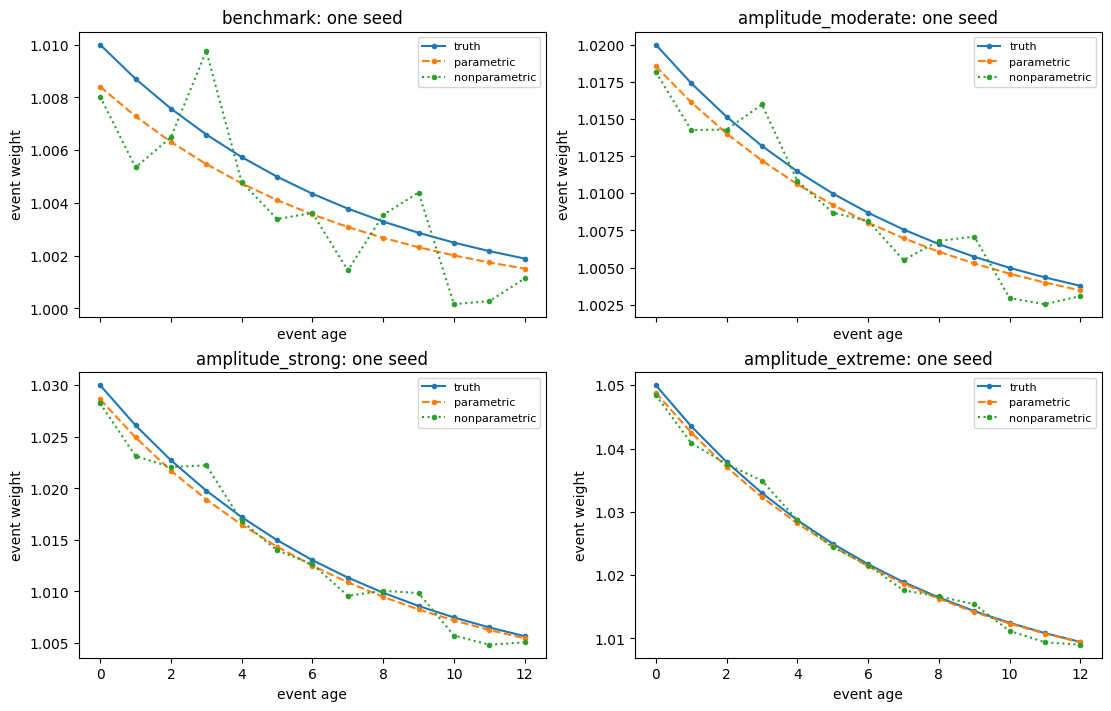

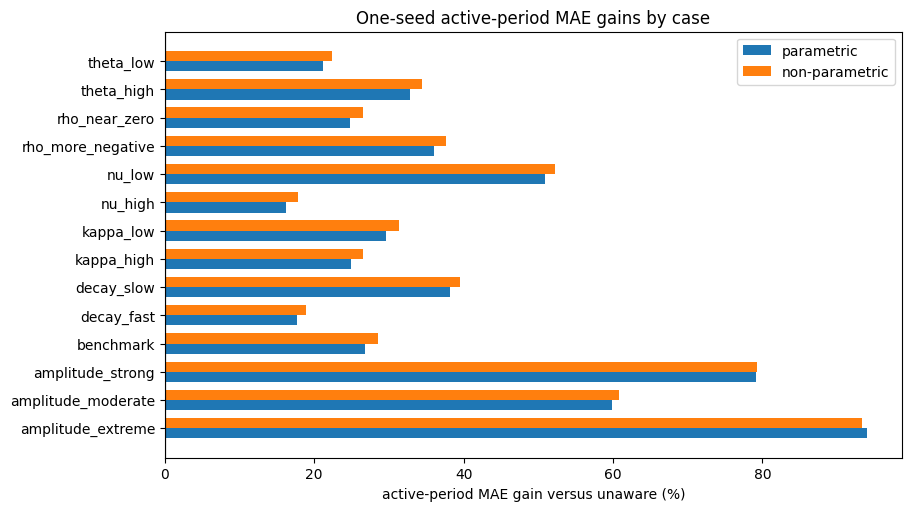

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11,7), sharex=True, constrained_layout=True)
for axis, case_name in zip(axes.ravel(), amplitude_cases):
    data = prototype_profiles.loc[prototype_profiles.case_name.eq(case_name)]
    for method, style in [('truth','-'),('parametric','--'),('nonparametric',':')]:
        subset = data.loc[data.profile_method.eq(method)]
        axis.plot(subset.event_age, subset.event_weight, linestyle=style, marker='o', markersize=3, label=method)
    axis.set(title=f'{case_name}: one seed', xlabel='event age', ylabel='event weight'); axis.legend(fontsize=8)
plt.show()
plot_data = prototype_results.sort_values('case_name')
fig, axis = plt.subplots(figsize=(9,5), constrained_layout=True)
y = np.arange(len(plot_data)); width = .36
axis.barh(y-width/2, plot_data['parametric_active_MAE_gain_pct'], height=width, label='parametric')
axis.barh(y+width/2, plot_data['nonparametric_active_MAE_gain_pct'], height=width, label='non-parametric')
axis.axvline(0,color='black',linewidth=.8); axis.set(yticks=y, yticklabels=plot_data.case_name, xlabel='active-period MAE gain versus unaware (%)', title='One-seed active-period MAE gains by case'); axis.legend()
plt.show()

## Prototype findings

This section reports only directly observed one-seed implementation status. All successful cases use exactly the same ordered test rows; interval metrics are explicitly labelled as state-space metrics; and the compact run-level table is ready for repeated-seed concatenation. It does not claim robust parameter effects or structural causality from GC or TDMI.

In [18]:
prototype_status = f"All 14 pipelines completed: {prototype_results.run_success.all()}. All successful cases share the benchmark's ordered test rows: {successful.common_test_rows.all()}. Profile fits converged: {prototype_results.profile_converged.all()}. Finite key metrics and complete profile schema: {np.isfinite(prototype_results.loc[prototype_results.run_success,['A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE']].to_numpy()).all() and len(prototype_profiles)==546}. State-space interval fields are populated, and the run-level table is ready for repeated-seed concatenation; no one-seed parameter effect is a robustness conclusion."
print(prototype_status)

All 14 pipelines completed: True. All successful cases share the benchmark's ordered test rows: True. Profile fits converged: True. Finite key metrics and complete profile schema: True. State-space interval fields are populated, and the run-level table is ready for repeated-seed concatenation; no one-seed parameter effect is a robustness conclusion.


## One-seed prototype checkpoint

The preceding one-seed prototype established that the frozen workflow, compact extraction schema, common-test-row validation, and preliminary figures work for all 14 scalar cases. The repeated-seed experiment below supplies the required robustness evidence without changing the benchmark, cases, estimator, timing, or forecast construction.

## Full 50-seed scalar-parameter experiment

The one-seed prototype established implementation validity but cannot establish statistical robustness. The complete frozen workflow is now repeated over

$$50\text{ seeds}\times14\text{ cases}=700\text{ runs}.$$

For each seed, one independent shock bank is generated; the benchmark is evaluated first; that shock bank is reused for the other 13 scalar cases; and every ordered test-row pair is compared with that seed's benchmark. The next seed uses a new independent shock bank. This provides paired within-seed comparisons while preserving independence across seeds. The design remains a one-at-a-time scalar experiment, not a factorial experiment.

## Execution and output controls

The full experiment is moderately expensive, so compact checkpoint files are overwritten after each completed seed. They protect against losing all progress if execution is interrupted, while a clean rerun from scratch remains possible.

In [19]:
from pathlib import Path
from time import perf_counter

RESULTS_DIR = Path('notebook08_results')
RESULTS_DIR.mkdir(exist_ok=True)
RUN_FULL_REPLICATION = False
RUN_CHECKPOINT_PATH = RESULTS_DIR / 'run_level_checkpoint.csv'
PROFILE_CHECKPOINT_PATH = RESULTS_DIR / 'event_age_profile_checkpoint.csv'
FAILURE_CHECKPOINT_PATH = RESULTS_DIR / 'failure_checkpoint.csv'
assert len(SEEDS) == 50
assert len(case_registry) == 14
assert len(SEEDS) * len(case_registry) == 700
# Set RUN_FULL_REPLICATION=False later to reload completed checkpoints without rerunning 700 pipelines.

## Prepare repeated-run storage

Only tidy summaries are retained: one row per seed and case, one row per seed-case-age-profile method, and one row per failed stage if failures occur. Full pipeline result dictionaries are not accumulated.

In [20]:
replication_rows = []
replication_profile_rows = []
replication_failure_rows = []
failure_columns = ['seed', 'case_name', 'parameter', 'parameter_value', 'failure_stage', 'exception_type', 'failure_message']

def write_replication_checkpoints():
    pd.DataFrame(replication_rows).to_csv(RUN_CHECKPOINT_PATH, index=False)
    pd.DataFrame(replication_profile_rows).to_csv(PROFILE_CHECKPOINT_PATH, index=False)
    pd.DataFrame(replication_failure_rows, columns=failure_columns).to_csv(FAILURE_CHECKPOINT_PATH, index=False)

## Execute the 700 runs

The benchmark runs first within every seed because it defines the paired benchmark metrics, ordered forecast test identifiers, and common-shock reference for that seed. Progress is printed once per completed seed. Failures are recorded honestly while the remaining runs continue.

In [21]:
if RUN_FULL_REPLICATION:
    ordered_registry = pd.concat([case_registry.loc[case_registry.case_name.eq('benchmark')], case_registry.loc[~case_registry.case_name.eq('benchmark')]], ignore_index=True)
    experiment_start = perf_counter()
    for seed_position, seed in enumerate(SEEDS, start=1):
        seed_start = perf_counter(); seed_shock_bank = make_shock_bank(benchmark_case, seed=seed); benchmark_ids_for_seed = None
        for _, registry_row in ordered_registry.iterrows():
            stage = 'configuration'; run_start = perf_counter()
            try:
                config = construct_scalar_case(registry_row); stage = 'pipeline'
                result = run_full_pipeline(config, shock_bank=seed_shock_bank, **pipeline_options)
                forecast_ids = result['forecasts'][['i', 'target_i']].reset_index(drop=True).copy()
                if registry_row.case_name == 'benchmark': benchmark_ids_for_seed, common_test_rows = forecast_ids, True
                else: common_test_rows = benchmark_ids_for_seed is not None and forecast_ids.equals(benchmark_ids_for_seed)
                stage = 'summary'; summary = summarise_case(result); stage = 'run-level extraction'
                run_row = extract_run_summary(result, summary, registry_row, seed, common_test_rows)
                stage = 'profile extraction'
                active_truth = result['truth']['table'].loc[result['truth']['table'].event_active_i.eq(1)]
                ages = np.arange(13); truth_weight = active_truth.groupby('event_age_i').m_true.mean().reindex(ages); profiles = result['profiles']; case_profile_rows = []
                for method, weights in [('truth', truth_weight), ('parametric', pd.Series(profiles['parametric_multiplier'](ages), index=ages)), ('nonparametric', profiles['nonparametric'].reindex(ages))]:
                    case_profile_rows.extend({'seed': seed, 'case_name': registry_row.case_name, 'parameter': registry_row.parameter, 'setting': registry_row.setting, 'parameter_value': registry_row.parameter_value, 'event_age': int(age), 'profile_method': method, 'event_weight': float(weight ** 2), 'volatility_multiplier': float(weight)} for age, weight in weights.items())
                stage = 'validation'; assert common_test_rows and len(truth_weight) == 13 and np.isfinite(truth_weight).all() and len(case_profile_rows) == 39
                run_row['run_runtime_seconds'], run_row['seed_runtime_seconds'] = perf_counter() - run_start, np.nan
                replication_rows.append(run_row); replication_profile_rows.extend(case_profile_rows)
            except Exception as exc:
                run_runtime = perf_counter() - run_start
                failure_row = {'seed': seed, 'case_name': registry_row.case_name, 'parameter': registry_row.parameter, 'setting': registry_row.setting, 'parameter_value': registry_row.parameter_value, 'benchmark_value': registry_row.benchmark_value, 'run_success': False, 'common_test_rows': False, 'failure_stage': stage, 'exception_type': type(exc).__name__, 'failure_message': str(exc), 'run_runtime_seconds': run_runtime, 'seed_runtime_seconds': np.nan}
                replication_rows.append(failure_row); replication_failure_rows.append({key: failure_row[key] for key in failure_columns})
            finally:
                if 'result' in locals(): del result
        seed_elapsed = perf_counter() - seed_start
        for row in replication_rows:
            if row['seed'] == seed: row['seed_runtime_seconds'] = seed_elapsed
        write_replication_checkpoints()
        successful_runs = sum(row.get('run_success', False) for row in replication_rows)
        print(f'Completed seed {seed_position}/50 | successful runs: {successful_runs}/{len(replication_rows)} | elapsed: {perf_counter() - experiment_start:.1f}s')
    replication_results = pd.DataFrame(replication_rows); replication_profiles = pd.DataFrame(replication_profile_rows); replication_failures = pd.DataFrame(replication_failure_rows, columns=failure_columns)
else:
    required_paths = [RUN_CHECKPOINT_PATH, PROFILE_CHECKPOINT_PATH, FAILURE_CHECKPOINT_PATH]
    missing_paths = [str(path) for path in required_paths if not path.exists()]
    if missing_paths: raise FileNotFoundError(f'Completed replication checkpoints are required: {missing_paths}')
    replication_results = pd.read_csv(RUN_CHECKPOINT_PATH); replication_profiles = pd.read_csv(PROFILE_CHECKPOINT_PATH); replication_failures = pd.read_csv(FAILURE_CHECKPOINT_PATH)

## Finalise and export raw repeated-seed outputs

The raw repeated-seed tables are the primary evidence for Notebook 08. They remain tidy, sorted, and free of duplicated seed-case observations; only compact summaries are exported.

In [22]:
replication_results = replication_results.sort_values(['seed', 'case_name']).reset_index(drop=True)
replication_profiles = replication_profiles.sort_values(['seed', 'case_name', 'profile_method', 'event_age']).reset_index(drop=True)
replication_failures = replication_failures.sort_values(['seed', 'case_name']).reset_index(drop=True)
replication_results.to_csv(RESULTS_DIR / 'notebook08_run_level_results.csv', index=False)
replication_profiles.to_csv(RESULTS_DIR / 'notebook08_event_age_profiles.csv', index=False)
replication_failures.to_csv(RESULTS_DIR / 'notebook08_failures.csv', index=False)

## Validate experiment completeness

The first full-sample checks concern implementation completeness rather than substantive model performance. They verify all intended combinations, paired comparisons, finite metrics, and profile schema integrity.

In [23]:
assert len(replication_results) == 700
assert not replication_results.duplicated(['seed', 'case_name']).any()
assert replication_results.groupby('seed').size().eq(14).all() and replication_results.groupby('case_name').size().eq(50).all()
successful_replications = replication_results.loc[replication_results.run_success.eq(True)].copy(); successful_run_count = len(successful_replications)
assert successful_replications.common_test_rows.eq(True).all()
key_metrics = ['A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE', 'baseline_active_sigma_MAE', 'known_dgp_active_sigma_RMSE']
assert np.isfinite(successful_replications[key_metrics].to_numpy(dtype=float)).all()
coverage_columns = ['parametric_active_95_state_coverage', 'nonparametric_active_95_state_coverage', 'known_dgp_active_95_state_coverage']; score_columns = ['parametric_active_95_state_interval_score', 'nonparametric_active_95_state_interval_score', 'known_dgp_active_95_state_interval_score']
assert successful_replications[coverage_columns].apply(lambda x: x.between(0, 1).all()).all() and (successful_replications[score_columns] >= 0).all().all() and successful_replications.profile_converged.eq(True).all()
assert set(replication_profiles.event_age) == set(range(13)) and set(replication_profiles.profile_method) == {'truth', 'parametric', 'nonparametric'}
assert not replication_profiles.duplicated(['seed', 'case_name', 'event_age', 'profile_method']).any()
expected_profile_rows = successful_run_count * 13 * 3; assert len(replication_profiles) == expected_profile_rows
experiment_completeness = pd.DataFrame([{'planned_runs': 700, 'attempted_runs': len(replication_results), 'successful_runs': successful_run_count, 'failed_runs': len(replication_results) - successful_run_count, 'success_rate': successful_run_count / 700, 'planned_seeds': 50, 'completed_seeds': replication_results.seed.nunique(), 'profile_rows': len(replication_profiles)}])
display(experiment_completeness)
if not replication_failures.empty: display(replication_failures)

,planned_runs,attempted_runs,successful_runs,failed_runs,success_rate,planned_seeds,completed_seeds,profile_rows
0,700,700,700,0,1.0,50,50,27300


## Define repeated-seed derived metrics

Detection indicators, timing recovery, forecast improvements, calibration error, and fitted-to-Known-DGP gaps are derived from stored run-level metrics only. No model is rerun for these transformations.

In [24]:
analysis_results = replication_results.copy(); success_mask = analysis_results.run_success.eq(True)
analysis_results['gc_level_detected_5pct'] = np.where(success_mask, analysis_results.gc_level_p_value < .05, np.nan)
analysis_results['gc_change_detected_5pct'] = np.where(success_mask, analysis_results.gc_change_p_value < .05, np.nan)
analysis_results['tdmi_change_peak_at_plus_1'] = np.where(success_mask, analysis_results.tdmi_change_direct_peak_lag.eq(1), np.nan)
analysis_results['tdmi_level_peak_in_direct_window'] = np.where(success_mask, analysis_results.tdmi_level_direct_peak_lag.between(1, 13), np.nan)
for model in ['parametric', 'nonparametric', 'known_dgp']:
    coverage = f'{model}_active_95_state_coverage'
    if coverage in analysis_results: analysis_results[f'{model}_95_state_coverage_error'] = (analysis_results[coverage] - .95).abs()
analysis_results['parametric_known_dgp_active_RMSE_gap'] = analysis_results.parametric_active_sigma_RMSE - analysis_results.known_dgp_active_sigma_RMSE
analysis_results['nonparametric_known_dgp_active_RMSE_gap'] = analysis_results.nonparametric_active_sigma_RMSE - analysis_results.known_dgp_active_sigma_RMSE
analysis_results['parametric_positive_MAE_gain'] = np.where(success_mask, analysis_results.parametric_active_MAE_gain_pct > 0, np.nan)
analysis_results['nonparametric_positive_MAE_gain'] = np.where(success_mask, analysis_results.nonparametric_active_MAE_gain_pct > 0, np.nan)

## Statistical summary helpers

Numeric metrics and binary detection rates require different uncertainty summaries. Means use standard errors and 95% Student-$t$ intervals, binary rates use 95% Wilson intervals, and empirical quantiles show distribution shape. These intervals quantify Monte Carlo variation over 50 simulated shock realisations, not uncertainty about real financial-market parameters.

In [25]:
from scipy.stats import t, norm

def summarise_numeric_series(series):
    values = pd.to_numeric(series, errors='coerce').dropna().to_numpy(dtype=float); count = len(values)
    mean = float(np.mean(values)) if count else np.nan; sd = float(np.std(values, ddof=1)) if count > 1 else np.nan
    se = sd / np.sqrt(count) if count > 1 else np.nan; critical = t.ppf(.975, count - 1) if count > 1 else np.nan
    return {'count': count, 'mean': mean, 'standard_deviation': sd, 'monte_carlo_standard_error': se, 'ci_95_lower': mean - critical * se if count > 1 else np.nan, 'ci_95_upper': mean + critical * se if count > 1 else np.nan, 'median': float(np.median(values)) if count else np.nan, 'q05': float(np.quantile(values, .05)) if count else np.nan, 'q25': float(np.quantile(values, .25)) if count else np.nan, 'q75': float(np.quantile(values, .75)) if count else np.nan, 'q95': float(np.quantile(values, .95)) if count else np.nan}

def wilson_interval(successes, count):
    if count == 0: return np.nan, np.nan
    z, rate = norm.ppf(.975), successes / count; denominator = 1 + z ** 2 / count
    centre = (rate + z ** 2 / (2 * count)) / denominator; radius = z * np.sqrt(rate * (1 - rate) / count + z ** 2 / (4 * count ** 2)) / denominator
    return centre - radius, centre + radius

def summarise_binary_series(series):
    values = pd.Series(series).dropna().astype(bool); count, successes = len(values), int(values.sum()); lower, upper = wilson_interval(successes, count)
    return {'count': count, 'successes': successes, 'rate': successes / count if count else np.nan, 'ci_95_lower': lower, 'ci_95_upper': upper}

## Build the case-level numeric summary

Each scalar case is summarised over its 50 independent seeds. The benchmark remains one underlying case rather than being duplicated across parameter families.

In [26]:
numeric_metrics = ['conditional_partial_r_squared', 'gc_level_partial_r_squared', 'gc_change_partial_r_squared', 'tdmi_level_direct_peak', 'tdmi_change_direct_peak', 'A_hat', 'A_relative_error', 'lambda_hat', 'lambda_relative_error', 'parametric_profile_MAE', 'parametric_profile_RMSE', 'nonparametric_profile_MAE', 'nonparametric_profile_RMSE', 'parametric_active_MAE_gain_pct', 'parametric_active_RMSE_gain_pct', 'nonparametric_active_MAE_gain_pct', 'nonparametric_active_RMSE_gain_pct', 'known_dgp_active_sigma_RMSE', 'parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap', 'parametric_active_95_state_coverage', 'parametric_95_state_coverage_error', 'parametric_active_95_state_interval_score', 'nonparametric_active_95_state_coverage', 'nonparametric_95_state_coverage_error', 'nonparametric_active_95_state_interval_score', 'known_dgp_active_95_state_coverage', 'known_dgp_95_state_coverage_error', 'known_dgp_active_95_state_interval_score']
summary_keys = ['case_name', 'parameter', 'setting', 'parameter_value']; numeric_rows = []
for key_values, group in analysis_results.loc[success_mask].groupby(summary_keys, dropna=False):
    key_data = dict(zip(summary_keys, key_values))
    for metric in numeric_metrics: numeric_rows.append({**key_data, 'metric': metric, **summarise_numeric_series(group[metric])})
numeric_summary = pd.DataFrame(numeric_rows)
numeric_summary.to_csv(RESULTS_DIR / 'notebook08_numeric_summary.csv', index=False)

## Build the detection-rate summary

Rejection frequency alone is insufficient and must be read with numeric partial-$R^2$ and TDMI summaries. This table reports binary frequencies with Wilson intervals.

In [27]:
detection_metrics = ['gc_level_detected_5pct', 'gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1', 'tdmi_level_peak_in_direct_window', 'parametric_positive_MAE_gain', 'nonparametric_positive_MAE_gain']; detection_rows = []
for key_values, group in analysis_results.loc[success_mask].groupby(summary_keys, dropna=False):
    key_data = dict(zip(summary_keys, key_values))
    for metric in detection_metrics: detection_rows.append({**key_data, 'metric': metric, **summarise_binary_series(group[metric])})
detection_summary = pd.DataFrame(detection_rows)
detection_summary.to_csv(RESULTS_DIR / 'notebook08_detection_summary.csv', index=False)

## Build paired benchmark contrasts

Common shocks allow every non-benchmark run to be compared directly with the same-seed benchmark:

$$D_{s,c}=M_{s,c}-M_{s,\mathrm{benchmark}}.$$

Higher forecast gain is better; lower profile RMSE, coverage error, interval score, and Known-DGP RMSE gap are better. The sign is therefore interpreted in the context of the metric.

In [28]:
paired_metrics = ['conditional_partial_r_squared', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE', 'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct', 'parametric_active_RMSE_gain_pct', 'nonparametric_active_RMSE_gain_pct', 'parametric_95_state_coverage_error', 'nonparametric_95_state_coverage_error', 'parametric_active_95_state_interval_score', 'nonparametric_active_95_state_interval_score', 'parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap']
paired_source = analysis_results.loc[success_mask].copy(); benchmark_by_seed = paired_source.loc[paired_source.case_name.eq('benchmark'), ['seed'] + paired_metrics].set_index('seed'); paired_rows = []
for _, case_row in paired_source.loc[~paired_source.case_name.eq('benchmark')].iterrows():
    benchmark_row = benchmark_by_seed.loc[case_row.seed]
    for metric in paired_metrics:
        paired_rows.append({'seed': case_row.seed, 'case_name': case_row.case_name, 'parameter': case_row.parameter, 'setting': case_row.setting, 'parameter_value': case_row.parameter_value, 'metric': metric, 'case_value': case_row[metric], 'benchmark_value': benchmark_row[metric], 'paired_difference': case_row[metric] - benchmark_row[metric]})
paired_contrasts_raw = pd.DataFrame(paired_rows); paired_summary_rows = []
for key_values, group in paired_contrasts_raw.groupby(summary_keys + ['metric'], dropna=False):
    key_data, stats = dict(zip(summary_keys + ['metric'], key_values)), summarise_numeric_series(group.paired_difference)
    paired_summary_rows.append({**key_data, 'count': stats['count'], 'mean_difference': stats['mean'], 'standard_deviation': stats['standard_deviation'], 'monte_carlo_standard_error': stats['monte_carlo_standard_error'], 'ci_95_lower': stats['ci_95_lower'], 'ci_95_upper': stats['ci_95_upper'], 'median_difference': stats['median'], 'q05': stats['q05'], 'q25': stats['q25'], 'q75': stats['q75'], 'q95': stats['q95']})
paired_contrast_summary = pd.DataFrame(paired_summary_rows)
paired_contrasts_raw.to_csv(RESULTS_DIR / 'notebook08_paired_contrasts_raw.csv', index=False)
paired_contrast_summary.to_csv(RESULTS_DIR / 'notebook08_paired_contrast_summary.csv', index=False)

## Aggregate event-age profiles

Amplitude and decay estimates can compensate for one another, so recovery of the complete fitted event profile is assessed across seeds. Each case-method-age distribution retains central tendency and spread.

In [29]:
profile_keys = ['case_name', 'parameter', 'setting', 'parameter_value', 'profile_method', 'event_age']
profile_long = replication_profiles.melt(id_vars=profile_keys, value_vars=['event_weight', 'volatility_multiplier'], var_name='profile_quantity', value_name='value')
profile_summary = profile_long.groupby(profile_keys + ['profile_quantity'], dropna=False)['value'].agg(count='count', mean='mean', median='median', q05=lambda x: x.quantile(.05), q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75), q95=lambda x: x.quantile(.95)).reset_index()
expected_profile_counts = successful_replications.groupby('case_name').size()
for case_name, count in expected_profile_counts.items(): assert profile_summary.loc[profile_summary.case_name.eq(case_name), 'count'].eq(count).all()
profile_summary.to_csv(RESULTS_DIR / 'notebook08_profile_summary.csv', index=False)

## Display compact aggregate tables

Only decision-relevant summaries are displayed here; complete tidy raw and summary tables are available as CSV exports.

In [30]:
display(experiment_completeness[['planned_runs', 'successful_runs', 'failed_runs', 'success_rate']])
display(detection_summary.loc[detection_summary.metric.isin(['gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1']), ['case_name', 'parameter_value', 'metric', 'rate', 'ci_95_lower', 'ci_95_upper']])
median_metrics = ['parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct']
forecast_display = numeric_summary.loc[numeric_summary.metric.isin(median_metrics), ['case_name', 'parameter_value', 'metric', 'median']].pivot(index=['case_name', 'parameter_value'], columns='metric', values='median').reset_index().rename(columns={'parametric_active_MAE_gain_pct': 'median_parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct': 'median_nonparametric_active_MAE_gain_pct'})
mean_metrics = ['parametric_active_95_state_coverage', 'parametric_active_95_state_interval_score']
forecast_means = numeric_summary.loc[numeric_summary.metric.isin(mean_metrics), ['case_name', 'metric', 'mean']].pivot(index='case_name', columns='metric', values='mean').reset_index().rename(columns={'parametric_active_95_state_coverage': 'mean_parametric_95_state_coverage', 'parametric_active_95_state_interval_score': 'mean_parametric_95_state_interval_score'})
gain_rates = detection_summary.loc[detection_summary.metric.isin(['parametric_positive_MAE_gain', 'nonparametric_positive_MAE_gain']), ['case_name', 'metric', 'rate']].pivot(index='case_name', columns='metric', values='rate').reset_index().rename(columns={'parametric_positive_MAE_gain': 'parametric_positive_gain_rate', 'nonparametric_positive_MAE_gain': 'nonparametric_positive_gain_rate'})
forecast_display = forecast_display.merge(gain_rates, on='case_name').merge(forecast_means, on='case_name').loc[:, ['case_name', 'parameter_value', 'median_parametric_active_MAE_gain_pct', 'parametric_positive_gain_rate', 'median_nonparametric_active_MAE_gain_pct', 'nonparametric_positive_gain_rate', 'mean_parametric_95_state_coverage', 'mean_parametric_95_state_interval_score']]
display(forecast_display)
recovery_metrics = ['A_relative_error', 'lambda_relative_error', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE']
recovery_display = numeric_summary.loc[numeric_summary.metric.isin(recovery_metrics), ['case_name', 'metric', 'median']].pivot(index='case_name', columns='metric', values='median').reset_index().rename(columns={'A_relative_error': 'median_A_relative_error', 'lambda_relative_error': 'median_lambda_relative_error', 'parametric_profile_RMSE': 'median_parametric_profile_RMSE', 'nonparametric_profile_RMSE': 'median_nonparametric_profile_RMSE'})
display(recovery_display)

,planned_runs,successful_runs,failed_runs,success_rate
0,700,700,0,1.0


,case_name,parameter_value,metric,rate,ci_95_lower,ci_95_upper
1,amplitude_extreme,0.0500,gc_change_detected_5pct,1.00,0.928652,1.000000
2,amplitude_extreme,0.0500,tdmi_change_peak_at_plus_1,0.82,0.692039,0.902298
7,amplitude_moderate,0.0200,gc_change_detected_5pct,1.00,0.928652,1.000000
8,amplitude_moderate,0.0200,tdmi_change_peak_at_plus_1,0.90,0.786398,0.956524
13,amplitude_strong,0.0300,gc_change_detected_5pct,1.00,0.928652,1.000000
14,amplitude_strong,0.0300,tdmi_change_peak_at_plus_1,0.96,0.865399,0.988961
19,benchmark,NaN,gc_change_detected_5pct,1.00,0.928652,1.000000
20,benchmark,NaN,tdmi_change_peak_at_plus_1,0.46,0.329697,0.596011
25,decay_fast,70.0000,gc_change_detected_5pct,1.00,0.928652,1.000000
26,decay_fast,70.0000,tdmi_change_peak_at_plus_1,0.72,0.583349,0.825258


metric,case_name,parameter_value,median_parametric_active_MAE_gain_pct,parametric_positive_gain_rate,median_nonparametric_active_MAE_gain_pct,nonparametric_positive_gain_rate,mean_parametric_95_state_coverage,mean_parametric_95_state_interval_score
0,amplitude_extreme,0.0500,94.174619,1.00,93.150039,1.00,0.925055,0.004683
1,amplitude_moderate,0.0200,59.954734,1.00,58.193607,1.00,0.943956,0.004246
2,amplitude_strong,0.0300,79.755751,1.00,78.100054,1.00,0.939560,0.004317
3,benchmark,NaN,22.416533,1.00,22.038878,0.98,0.944615,0.004199
4,decay_fast,70.0000,12.436139,0.98,10.925671,0.92,0.940000,0.004194
5,decay_slow,17.5000,36.150070,1.00,34.898813,1.00,0.945275,0.004213
6,kappa_high,3.0000,19.006193,1.00,16.441667,0.98,0.941978,0.004168
7,kappa_low,0.7500,27.545630,1.00,25.527102,0.98,0.943516,0.004240
8,nu_high,0.0225,12.363474,0.96,9.594169,0.92,0.942198,0.006304
9,nu_low,0.0075,49.255712,1.00,47.666760,1.00,0.945055,0.002101


metric,case_name,median_A_relative_error,median_lambda_relative_error,median_nonparametric_profile_RMSE,median_parametric_profile_RMSE
0,amplitude_extreme,0.000451,-0.005931,0.000611,0.000269
1,amplitude_moderate,-0.002298,-0.000086,0.000898,0.000379
2,amplitude_strong,0.002518,-0.005709,0.000775,0.000344
3,benchmark,-0.007859,0.001963,0.001028,0.000425
4,decay_fast,-0.017359,-0.010845,0.001091,0.000473
5,decay_slow,0.006205,0.010062,0.000978,0.000429
6,kappa_high,-0.012935,-0.012372,0.001097,0.000466
7,kappa_low,-0.006776,0.006223,0.000990,0.000404
8,nu_high,-0.012794,0.002482,0.001544,0.000643
9,nu_low,-0.002545,0.000269,0.000517,0.000219


## Create plot ordering metadata

Plots follow scientific parameter order rather than alphabetical case-name order. The benchmark is retained once in raw tables but may appear in each family view for comparison.

In [31]:
family_order = ['kappa', 'theta', 'nu', 'rho', 'amplitude', 'decay_rate']
family_case_order = {'kappa': ['kappa_low', 'benchmark', 'kappa_high'], 'theta': ['theta_low', 'benchmark', 'theta_high'], 'nu': ['nu_low', 'benchmark', 'nu_high'], 'rho': ['rho_more_negative', 'benchmark', 'rho_near_zero'], 'amplitude': ['benchmark', 'amplitude_moderate', 'amplitude_strong', 'amplitude_extreme'], 'decay_rate': ['decay_slow', 'benchmark', 'decay_fast']}
plot_case_order = []
for family in family_order: plot_case_order.extend(case for case in family_case_order[family] if case not in plot_case_order)
assert set(plot_case_order) == set(case_registry.case_name)

## Figure 1 — Detection robustness

Event detection is evaluated across shock realisations. Rates are shown with Wilson uncertainty and do not imply structural causality.

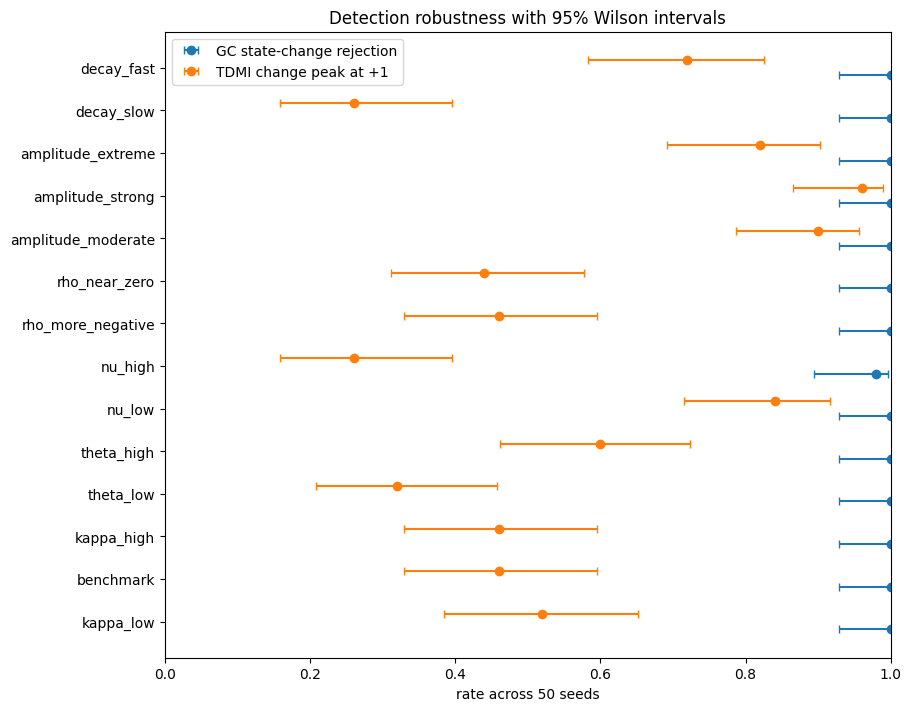

In [32]:
final_figures = {}
detection_plot = detection_summary.loc[detection_summary.metric.isin(['gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1'])].pivot(index='case_name', columns='metric', values=['rate', 'ci_95_lower', 'ci_95_upper']).reindex(plot_case_order)
fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True); y = np.arange(len(plot_case_order))
for offset, metric, label in zip([-.18, .18], ['gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1'], ['GC state-change rejection', 'TDMI change peak at +1']):
    rate, lower, upper = (detection_plot[(field, metric)].to_numpy() for field in ['rate', 'ci_95_lower', 'ci_95_upper'])
    axis.errorbar(rate, y + offset, xerr=np.vstack([rate - lower, upper - rate]), fmt='o', capsize=3, label=label)
axis.set(yticks=y, yticklabels=plot_case_order, xlim=(0, 1), xlabel='rate across 50 seeds', title='Detection robustness with 95% Wilson intervals'); axis.legend()
final_figures['detection_robustness.png'] = fig
plt.show()

## Figure 2 - Event-profile recovery

Profile RMSE evaluates recovery of the complete event-response shape, which is more informative than considering $\widehat A$ or $\widehat\lambda$ separately.

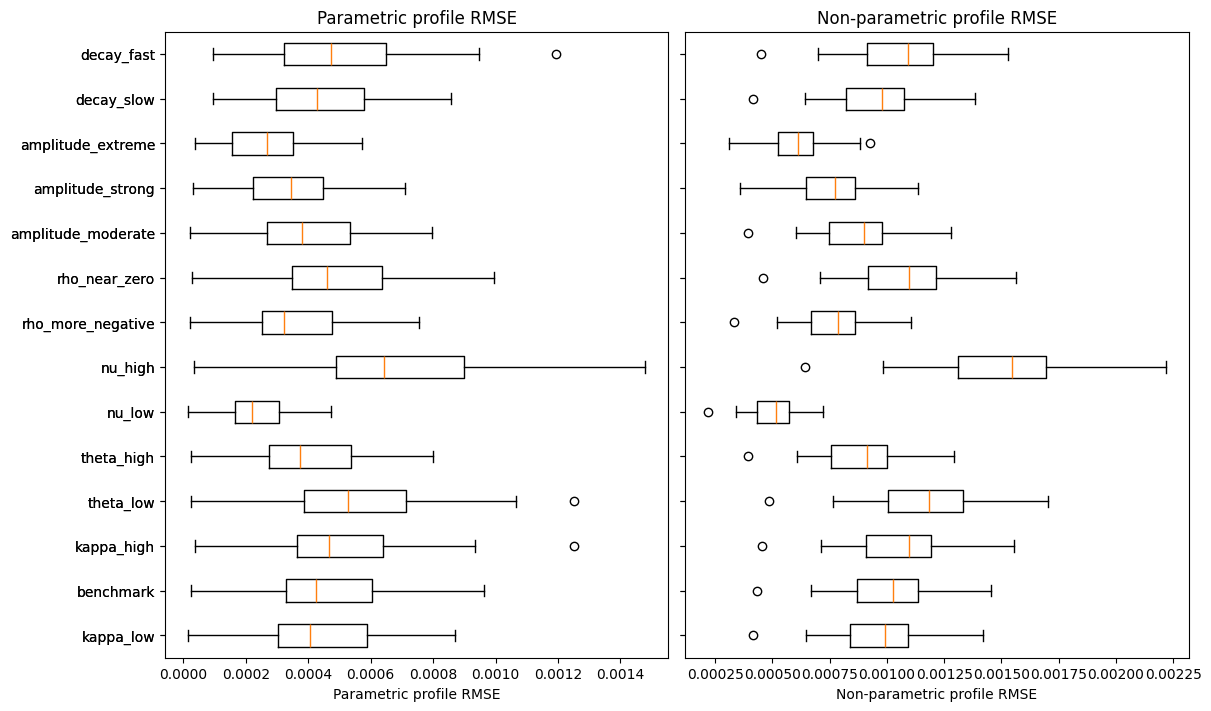

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
for axis, metric, label in zip(axes, ['parametric_profile_RMSE', 'nonparametric_profile_RMSE'], ['Parametric profile RMSE', 'Non-parametric profile RMSE']):
    data = [analysis_results.loc[success_mask & analysis_results.case_name.eq(case), metric].dropna() for case in plot_case_order]
    axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.set(xlabel=label, title=label)
final_figures['profile_rmse.png'] = fig
plt.show()

## Figure 3 — Forecast gains

Positive gain means an event-aware forecast improves on the event-unaware baseline during active event periods. The distribution across seeds is more informative than a single average, and negative outcomes are retained.

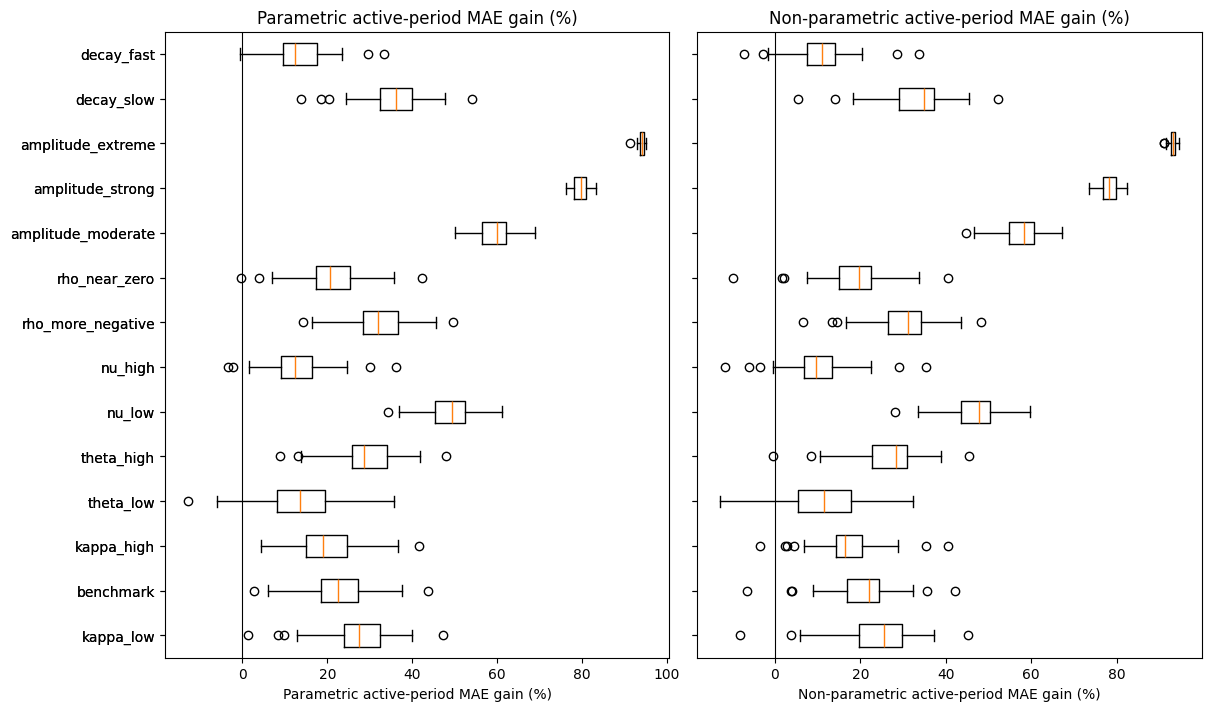

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
for axis, metric, label in zip(axes, ['parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct'], ['Parametric active-period MAE gain (%)', 'Non-parametric active-period MAE gain (%)']):
    data = [analysis_results.loc[success_mask & analysis_results.case_name.eq(case), metric].dropna() for case in plot_case_order]
    axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.axvline(0, color='black', linewidth=.8); axis.set(xlabel=label, title=label)
final_figures['forecast_mae_gains.png'] = fig
plt.show()

## Figure 4 — Calibration

Coverage should be close to 95%, but coverage alone can improve artificially through excessively wide intervals. Coverage error and interval score are therefore shown separately.

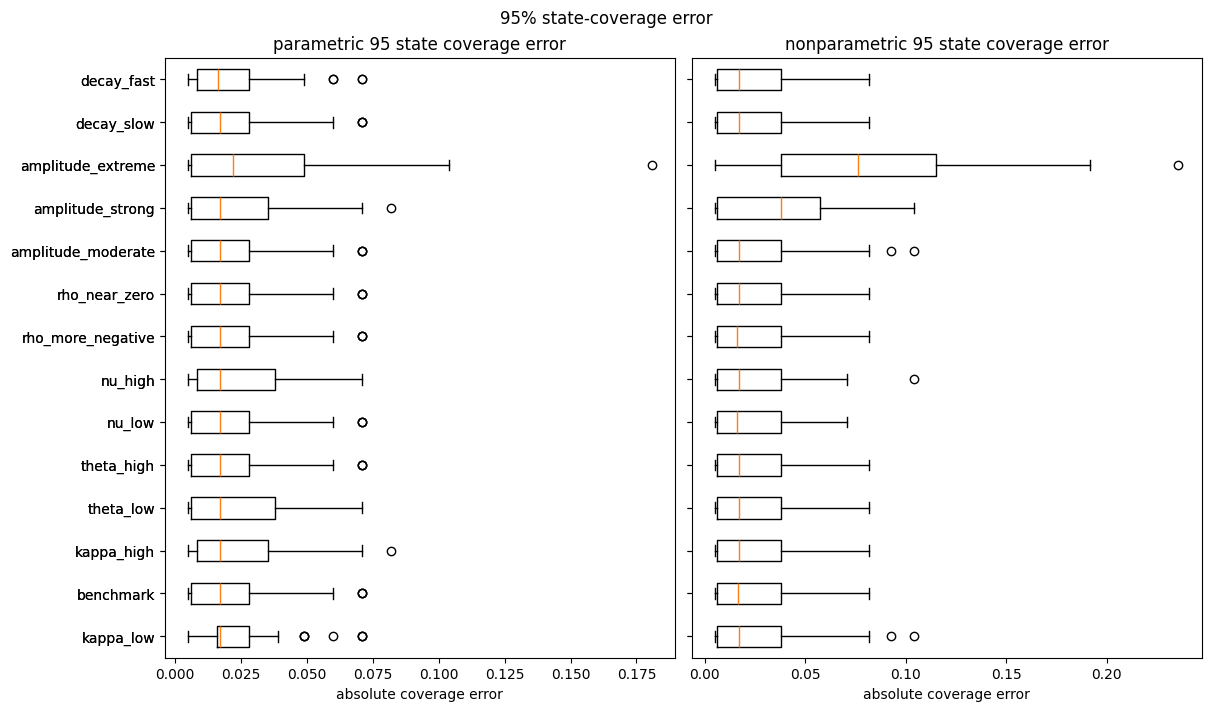

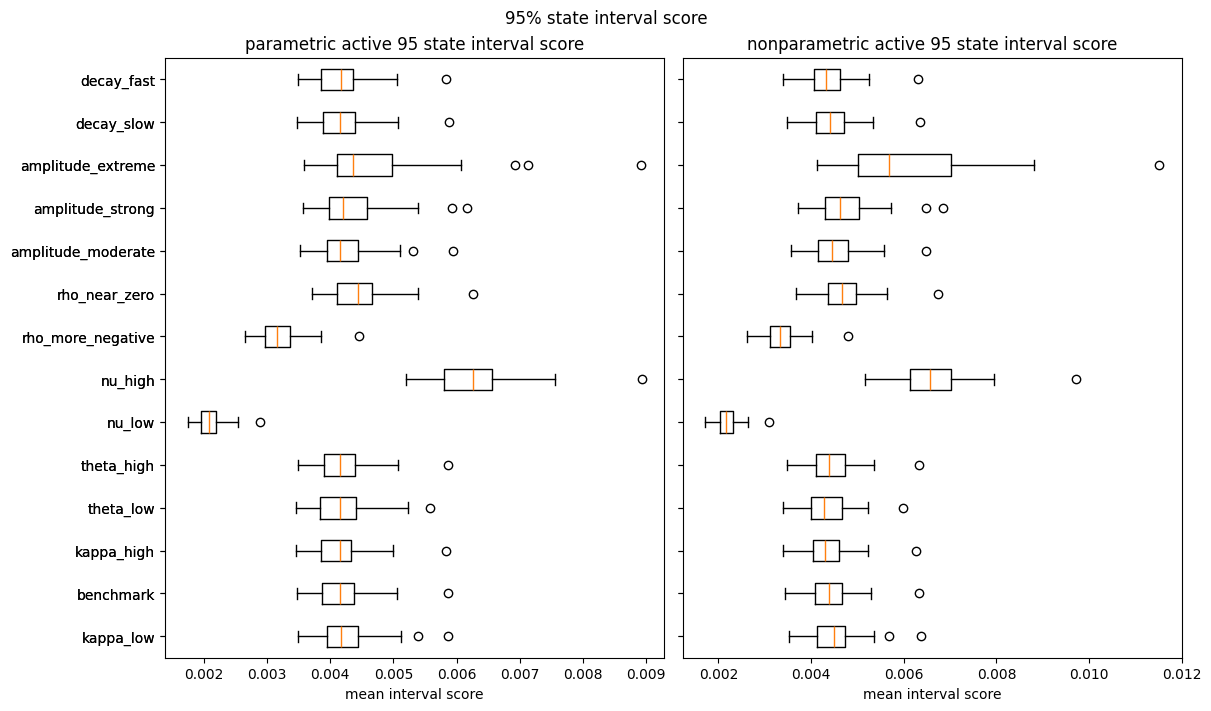

In [35]:
for filename, metrics, title, xlabel in [('coverage_error.png', ['parametric_95_state_coverage_error', 'nonparametric_95_state_coverage_error'], '95% state-coverage error', 'absolute coverage error'), ('interval_scores.png', ['parametric_active_95_state_interval_score', 'nonparametric_active_95_state_interval_score'], '95% state interval score', 'mean interval score')]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
    for axis, metric in zip(axes, metrics):
        data = [analysis_results.loc[success_mask & analysis_results.case_name.eq(case), metric].dropna() for case in plot_case_order]
        axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.set(xlabel=xlabel, title=metric.replace('_', ' '))
    fig.suptitle(title); final_figures[filename] = fig; plt.show()

## Figure 5 - Mean event profiles by parameter family

Each family view shows how the fitted response changes when one scalar parameter varies and all others remain fixed. Truth is used only as an evaluation reference; fitted methods retain 5th–95th percentile bands.

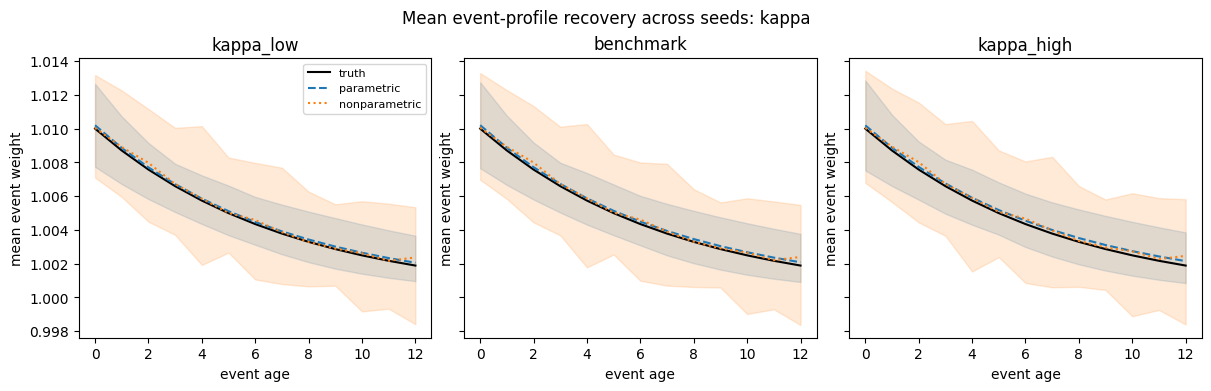

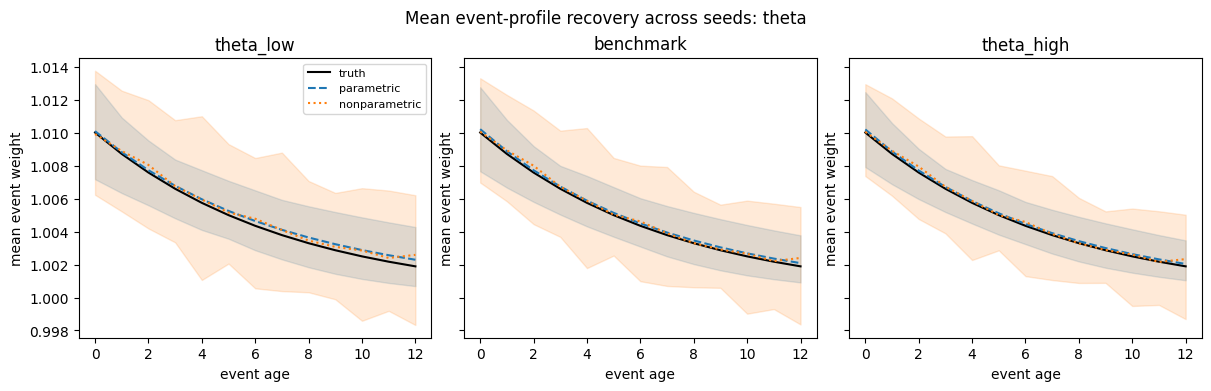

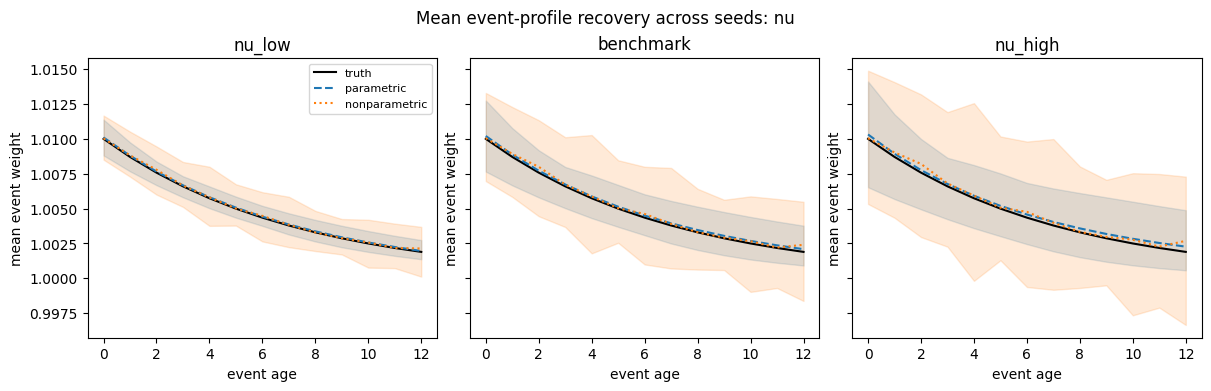

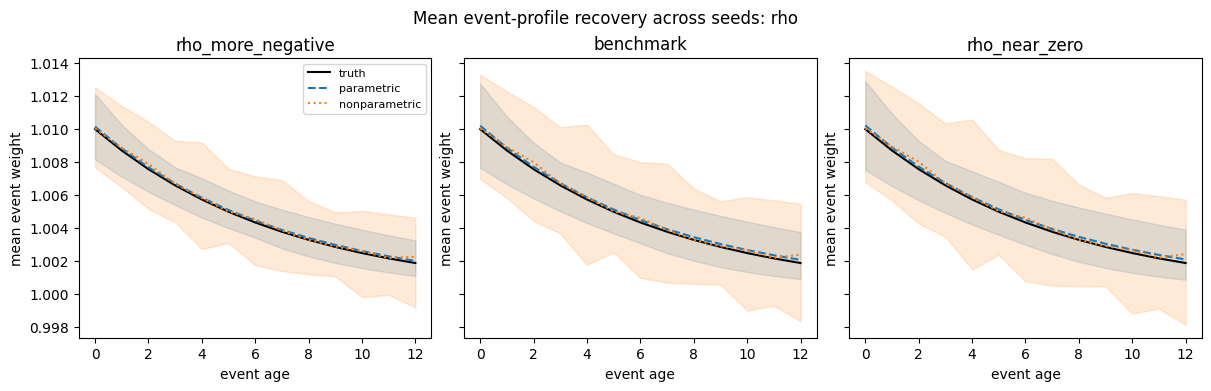

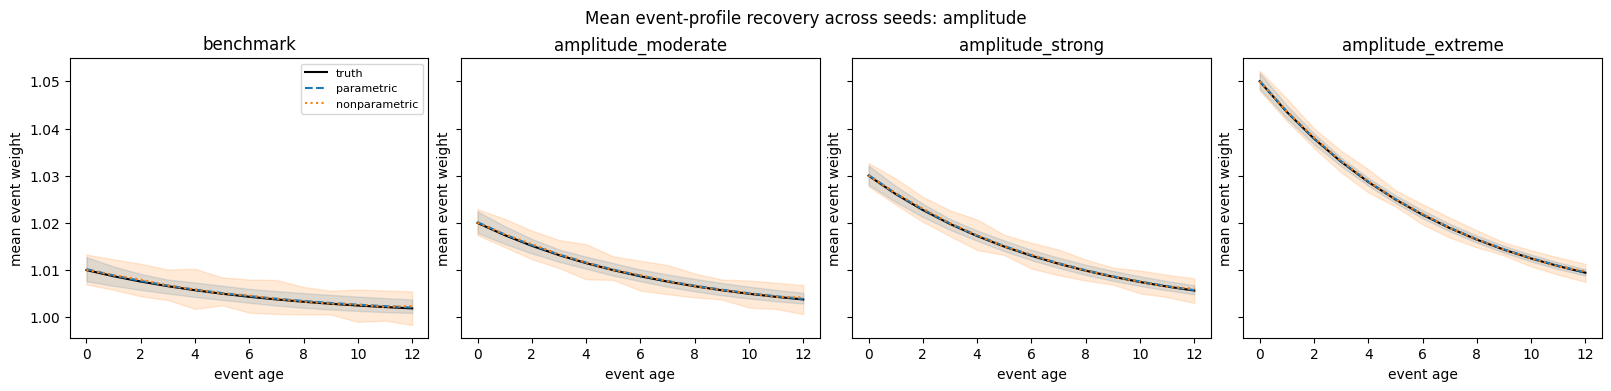

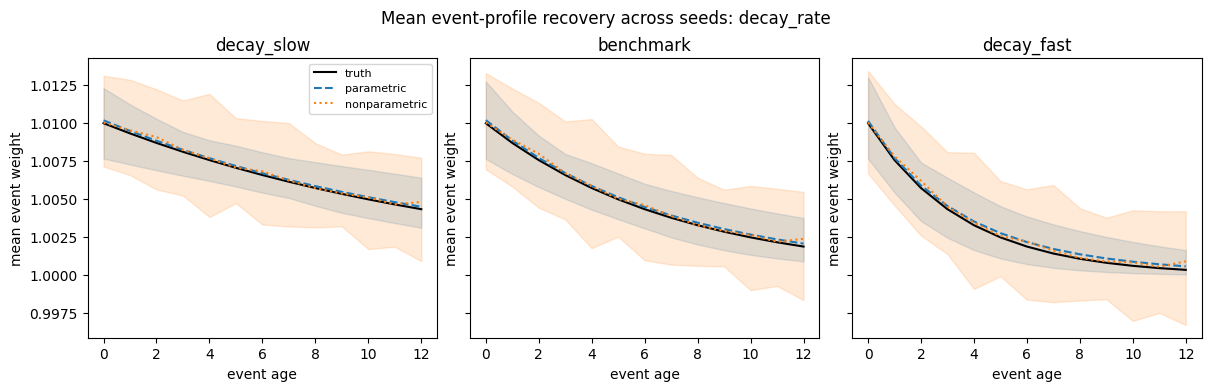

In [36]:
for family in family_order:
    family_cases = family_case_order[family]
    fig, axes = plt.subplots(1, len(family_cases), figsize=(4 * len(family_cases), 3.8), sharey=True, constrained_layout=True); axes = np.atleast_1d(axes)
    for axis, case_name in zip(axes, family_cases):
        data = profile_summary.loc[(profile_summary.case_name.eq(case_name)) & (profile_summary.profile_quantity.eq('event_weight'))]
        for method, style, color in [('truth', '-', 'black'), ('parametric', '--', 'tab:blue'), ('nonparametric', ':', 'tab:orange')]:
            subset = data.loc[data.profile_method.eq(method)].sort_values('event_age')
            axis.plot(subset.event_age, subset['mean'], linestyle=style, color=color, label=method)
            if method != 'truth': axis.fill_between(subset.event_age, subset.q05, subset.q95, color=color, alpha=.16)
        axis.set(title=case_name, xlabel='event age', ylabel='mean event weight')
    axes[0].legend(fontsize=8); fig.suptitle(f'Mean event-profile recovery across seeds: {family}')
    final_figures[f'profile_{family}.png'] = fig
    plt.show()

## Figure 6 — Known-DGP forecasting gap

The Known-DGP reference is a truth-based evaluation benchmark unavailable to fitted models. The fitted-to-Known-DGP RMSE gap shows residual forecast error from estimating the event response and other components; small negative values, if present, are retained.

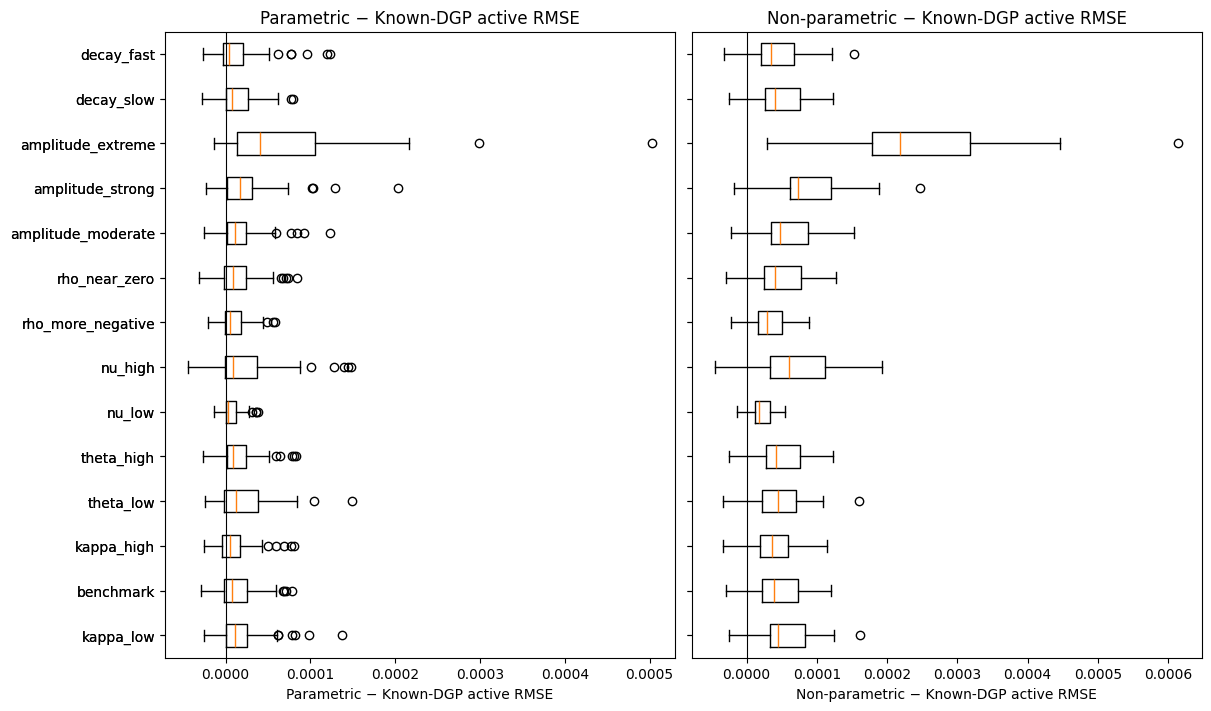

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
for axis, metric, label in zip(axes, ['parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap'], ['Parametric − Known-DGP active RMSE', 'Non-parametric − Known-DGP active RMSE']):
    data = [analysis_results.loc[success_mask & analysis_results.case_name.eq(case), metric].dropna() for case in plot_case_order]
    axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.axvline(0, color='black', linewidth=.8); axis.set(xlabel=label, title=label)
final_figures['known_dgp_rmse_gap.png'] = fig
plt.show()

## Save final robustness figures

The final repeated-seed figures are saved at reasonable resolution for use outside the notebook. Earlier one-seed prototype figures are not included in this final robustness export.

In [38]:
FIGURES_DIR = RESULTS_DIR / 'figures'; FIGURES_DIR.mkdir(exist_ok=True)
for filename, figure in final_figures.items(): figure.savefig(FIGURES_DIR / filename, dpi=180, bbox_inches='tight')
assert {'detection_robustness.png', 'profile_rmse.png', 'forecast_mae_gains.png', 'coverage_error.png', 'interval_scores.png', 'known_dgp_rmse_gap.png', 'profile_amplitude.png', 'profile_decay_rate.png'}.issubset(final_figures)

## Paired parameter-sensitivity evidence

Every alternative case is compared with its benchmark counterpart from the same seed:

$$D_{s,c}=M_{s,c}-M_{s,\mathrm{benchmark}}.$$

The 95% interval describes Monte Carlo uncertainty in the mean paired difference over 50 seeds. It is a compact supplement to the complete exported paired-contrast table.

In [39]:
paired_evidence_metrics = [
    'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct',
    'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_95_state_coverage_error', 'nonparametric_95_state_coverage_error',
    'parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap',
]
paired_evidence = paired_contrast_summary.loc[
    paired_contrast_summary['metric'].isin(paired_evidence_metrics),
    ['case_name', 'parameter', 'parameter_value', 'metric', 'mean_difference', 'ci_95_lower', 'ci_95_upper', 'median_difference'],
].sort_values(['parameter', 'parameter_value', 'metric'])
display(paired_evidence)

,case_name,parameter,parameter_value,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
14,amplitude_moderate,amplitude,0.02,nonparametric_95_state_coverage_error,0.004110,0.001432,0.006788,0.000000
16,amplitude_moderate,amplitude,0.02,nonparametric_active_MAE_gain_pct,37.005302,35.732947,38.277656,36.954734
18,amplitude_moderate,amplitude,0.02,nonparametric_known_dgp_active_RMSE_gap,0.000016,0.000012,0.000020,0.000014
19,amplitude_moderate,amplitude,0.02,nonparametric_profile_RMSE,-0.000136,-0.000146,-0.000126,-0.000137
20,amplitude_moderate,amplitude,0.02,parametric_95_state_coverage_error,0.001099,-0.000923,0.003121,0.000000
...,...,...,...,...,...,...,...,...
149,theta_high,theta,0.25,nonparametric_profile_RMSE,-0.000121,-0.000130,-0.000113,-0.000121
150,theta_high,theta,0.25,parametric_95_state_coverage_error,0.000923,-0.000312,0.002158,0.000000
152,theta_high,theta,0.25,parametric_active_MAE_gain_pct,6.134428,5.828293,6.440564,6.044813
154,theta_high,theta,0.25,parametric_known_dgp_active_RMSE_gap,0.000001,-0.000001,0.000003,0.000001


## Repeated-seed findings

### Numerical robustness

All 700 pipelines completed, all common test-row checks passed, profile convergence was 100%, and all 27,300 expected event-profile rows were produced. No failure case was excluded.

### Predictive-structure robustness

GC state-change rejection was effectively saturated: 100% for every case except `nu_high` (98%). Binary rejection therefore has little ability to distinguish most parameter cases in this design; GC partial $R^2$, rather than rejection alone, is required to compare predictive effect size.

State-change TDMI peak-at-$+1$ rates were: benchmark 46%; `amplitude_moderate` 90%; `amplitude_strong` 96%; `amplitude_extreme` 82%; `nu_low` 84%; `nu_high` 26%; `decay_slow` 26%; `decay_fast` 72%; `theta_low` 32%; `theta_high` 60%; `rho_more_negative` 46%; and `rho_near_zero` 44%. Stronger amplitude generally improves direct timing recovery, although not monotonically at the extreme amplitude. Lower innovation noise sharply improves timing recovery; faster decay produces a sharper early response, while slower decay spreads dependence across more lags. GC and TDMI remain predictive-dependence measures, not proof of structural causality.

### Event-profile recovery

The parametric profile estimator has lower median profile RMSE than the non-parametric estimator in all 14 cases. Benchmark medians are approximately 0.000425 (parametric) and 0.001028 (non-parametric). `nu_low` gives the strongest recovery, at approximately 0.000219 and 0.000517 respectively, whereas `nu_high` gives the weakest, at approximately 0.000643 and 0.001544. Increasing amplitude reduces profile RMSE; `amplitude_extreme` has parametric median RMSE of approximately 0.000269.

For `theta_low`, the median relative amplitude error is approximately -3.0% and the median relative decay-rate error approximately -8.5%. These larger individual errors alongside a still-moderate full-profile RMSE are consistent with partial compensation between amplitude and decay, rather than definitive parameter non-identifiability.

### Forecast robustness

Benchmark median active-period MAE gains are approximately 22.42% for the parametric model and 22.04% for the non-parametric model. The parametric gain is positive in all 50 benchmark seeds; the non-parametric gain is positive in 49 of 50.

The parametric amplitude progression is approximately 59.95% at $A=0.02$, 79.76% at $A=0.03$, and 94.17% at $A=0.05$. The main signal-to-noise pattern is 49.26% for `nu_low` versus 12.36% for `nu_high`; the persistence pattern is 36.15% for `decay_slow` versus 12.44% for `decay_fast`. Additional parametric median gains are approximately 27.55% (`kappa_low`), 19.01% (`kappa_high`), 31.84% (`rho_more_negative`), 20.57% (`rho_near_zero`), 28.55% (`theta_high`), and 13.54% (`theta_low`).

Paired intervals identify persistent changes relative to the benchmark: `amplitude_extreme` raises parametric MAE gain by approximately 71.25 percentage points (95% interval [69.20, 73.30]), while `nu_high` lowers it by approximately 9.99 points ([-10.56, -9.43]). One-at-a-time sensitivity does not establish interactions.

### Calibration

For the benchmark parametric interval, mean 95% state coverage is approximately 94.5%, mean absolute coverage error 0.022, and mean interval score 0.00420. Coverage remains close to 95% for most cases. Notable cases are `amplitude_extreme` (approximately 92.5% coverage and 0.00468 score), `nu_high` (94.2% and 0.00630), and `nu_low` (94.5% and 0.00210). Coverage and interval score must be interpreted together.

Raw interval scores and absolute RMSE values partly depend on the scale of the simulated volatility process. Comparisons across materially different volatility scales should therefore be read with relative forecast gains, coverage error, same-seed paired contrasts, and the Known-DGP reference; a larger raw interval score is not automatically pure estimator deterioration.

### Known-DGP reference gap

The benchmark median parametric active-period RMSE gap from the Known-DGP reference is approximately 0.00000813. Fitted estimators are generally close to this truth-based forecasting reference, but the gap increases in more difficult settings such as higher innovation noise and can be more dispersed under extreme amplitude. Small negative gaps are retained as finite-sample outcomes. The Known-DGP reference is not an available real-data forecasting method.

### Overall parameter sensitivity

The most influential scalar dimensions are event amplitude, volatility innovation scale, and event decay rate: they materially alter detectability, profile recovery, and event-aware forecast gains. $\kappa$, $\theta$, and $\rho$ also affect forecast gains, while $\rho$ has little effect on the binary TDMI timing rate here. Binary GC rejection is too saturated to rank most cases; profile RMSE and relative forecast gain are more discriminating robustness measures. Paired intervals distinguish persistent changes from Monte Carlo noise, and no result automatically transfers to real market data.

## Limitations

Only 50 shock realisations are used. Parameters vary one at a time, so interaction effects are not studied; the event calendar remains dense and deterministic; and the results are synthetic and do not establish empirical market causality. The strongest amplitude is a deliberate stress case, the experiment remains $n=1$, and the Known-DGP reference is available only in simulation.

Absolute RMSE and interval-score comparisons are partly scale-dependent across simulated volatility regimes. Fifty seeds provide useful Monte Carlo evidence but relatively wide uncertainty for binary rates; the deterministic periodic event calendar may make GC rejection unusually powerful; and the scalar experiment does not identify interaction effects.

## Final Notebook 08 checkpoint

Notebook 08 now completes one-at-a-time scalar robustness over 50 independent seeds and 700 planned full-pipeline runs, paired common-shock comparisons, detection-rate analysis, event-profile recovery, event-aware forecasting, calibration, Known-DGP gap evaluation, final robustness figures, and exported raw and summary tables.

All 700 runs completed successfully. Notebook 08 is complete because raw-result checks and aggregation assertions pass, figures render, and findings are generated from repeated-seed outputs. The next roadmap notebook is `09_n2_full_analysis.ipynb`; it is not created or started here.

In [40]:
print(f'Notebook 08 completion status: {successful_run_count}/700 successful runs; figures saved: {len(final_figures)}; raw and summary tables exported to {RESULTS_DIR}.')

Notebook 08 completion status: 700/700 successful runs; figures saved: 12; raw and summary tables exported to notebook08_results.
